In [45]:
import os
import pandas as pd
import numpy as np
import torch
#torchvision, torchaudio installed
from tqdm import tqdm

In [46]:
print(torch.__version__)
print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built()) #checks if your current PyTorch installation was compiled with support for the MPS backend

device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")
torch.mps.empty_cache()

2.10.0
True
True
Using device: mps


In [47]:
import warnings
import nltk
SEED = 0
torch.manual_seed(SEED)
torch.mps.manual_seed(SEED)
torch.use_deterministic_algorithms(True)
warnings.filterwarnings('ignore')
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jessie_guo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [90]:
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer, EarlyStoppingCallback

SAVE_OUTPUT = "distilbert_finetuned-goemotions-final_shaver_multilabel_loss"

def save_to_device(SAVE_OUTPUT):
    model_new = AutoModelForSequenceClassification.from_pretrained(SAVE_OUTPUT)
    tokenizer_new = AutoTokenizer.from_pretrained(SAVE_OUTPUT)
    return model_new, tokenizer_new

model_new, tokenizer_new = save_to_device(SAVE_OUTPUT)

model_new.to(device)
model_new.eval()

Loading weights: 100%|█████████| 104/104 [00:00<00:00, 9190.48it/s]


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [91]:
from torch.utils.data import Dataset
class CustomDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.dataframe = dataframe
        self.texts = dataframe['text']
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = str(self.texts.iloc[index])
        text = " ".join(text.split())
        inputs = self.tokenizer(
            text,
            None,
            add_special_tokens=True,  # Add special tokens
            max_length=self.max_len,
            padding='max_length',  # Pad to max_length
            return_token_type_ids=True,
            return_tensors='pt',  # Return PyTorch tensors
            truncation=True  # Truncate sequences longer than max_length
        )
        
        input_ids = inputs['input_ids'].squeeze(0)  # Remove the added batch dimension
        attention_mask = inputs['attention_mask'].squeeze(0)  # Remove the added batch dimension
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
        }

In [92]:
def test(test_loader):
    model_new.eval()
    all_outputs = []
    with torch.no_grad():
        for data in test_loader:
            input_ids = data['input_ids'].to(device) #, dtype=torch.long)
            attention_mask = data['attention_mask'].to(device) #, dtype=torch.long)
            outputs = model_new(input_ids = input_ids, attention_mask = attention_mask)
            logits = outputs.logits

            if PROBLEM_TYPE == "multi_label_classification":
                probs = torch.sigmoid(logits)
                all_outputs.extend(probs.cpu().numpy().tolist())
            elif PROBLEM_TYPE == "single_label_classification":
                probs = torch.softmax(logits, dim = -1)
                predictions = torch.argmax(probs, dim = -1)
                all_outputs.extend(predictions.cpu().numpy().tolist())  
    
    return all_outputs

In [93]:
from datasets import load_dataset
go_emotions = load_dataset("go_emotions")
lengths = [len(tokenizer_new.encode(text)) for text in go_emotions['train']['text']]
print(max(lengths)) #max token count across all texts
print("95th percentile:", np.percentile(lengths, 95)) #95% of samples contain 34 tokens or fewer 

MAX_LEN = 128

316
95th percentile: 34.0


In [119]:
texts_path = 'Data/Georgian/GeorgianNews/'
sources = ['orig/', 'en/', 'ggl/', 'gem/', 'gpt/']
#ge_1tv_csv = texts_path + "ge/ge_original_1tv_news/combined_all_articles_ge.csv"
#ge_IPN_csv = texts_path + "ge/ge_original_IPN_news/IPN_news_combined_master_ge_renamed.csv"

#df_1tv_ge = pd.read_csv(ge_1tv_csv)
#df_IPN_ge = pd.read_csv(ge_IPN_csv)

#df_ge = pd.concat([df_1tv_ge, df_IPN_ge], axis = 0)
#print(df_ge.head())
#print(df_ge.columns)

def combine_news(lang_1tv, lang_ipn):
    onetv_lang = pd.read_csv(lang_1tv)
    ipn_lang = pd.read_csv(lang_ipn)
    
    df_ge = pd.concat([onetv_lang, ipn_lang], axis = 0)
    print(df_ge.head())
    print(df_ge.columns)
    return df_ge

df_orig = combine_news(texts_path + "orig/ge_original_1tv_news/combined_all_articles_ge.csv", texts_path + "orig/ge_original_IPN_news/IPN_news_combined_master_ge_renamed.csv")
df_en = combine_news(texts_path + "en/eng_expert_1tv_news/combined_all_articles_eng.csv", texts_path + "en/eng_expert_IPN_news/IPN_news_combined_master_eng_renamed.csv")
df_gem = combine_news(texts_path + "gem/gem_1tv_news/combined_all_articles_gem.csv", texts_path + "gem/gem_IPN_news/IPN_news_combined_master_gem_renamed.csv")
df_ggl = combine_news(texts_path + "ggl/ggl_1tv_news/combined_all_articles_ggl.csv", texts_path + "ggl/ggl_IPN_news/IPN_news_combined_master_ggl_renamed.csv")
df_gpt = combine_news(texts_path + "gpt/gpt_1tv_news/combined_all_articles_gpt.csv", texts_path + "gpt/gpt_IPN_news/IPN_news_combined_master_gpt_renamed.csv")
article_names = sorted(df_orig["Source File"].unique())
print(article_names)
#print(len(article_names))
#print(df_en)

                      Source File  \
0  01_deputy_economy_minister.csv   
1  01_deputy_economy_minister.csv   
2  01_deputy_economy_minister.csv   
3  01_deputy_economy_minister.csv   
4  01_deputy_economy_minister.csv   

                                             Content  
0  ვახტანგ ცინცაძე - აზიის განვითარების ბანკის ან...  
1  აზიის განვითარების ბანკმა აზიის ეკონომიკური პე...  
2  როგორც მინისტრის მოადგილემ აღნიშნა, აზიის განვ...  
3  ვახტანგ ცინცაძის განცხადებით,  2026 წელს აზიის...  
4  „აზიის განვითარების ბანკი ასევე ხაზგასმით აღნი...  
Index(['Source File', 'Content'], dtype='object')
                      Source File  \
0  01_deputy_economy_minister.csv   
1  01_deputy_economy_minister.csv   
2  01_deputy_economy_minister.csv   
3  01_deputy_economy_minister.csv   
4  01_deputy_economy_minister.csv   

                                             Content  
0  Deputy Economy Minister: ADB highlights Georgi...  
1  “The Asian Development Bank (ADB) has publishe...  
2  The De

In [53]:
#EKMAN MAPPING
import json
import pandas as pd
import numpy as np

with open("ekman_mapping.json", "r", encoding="utf-8") as f:
    ekman_mapping = json.load(f)

# Add neutral if not already present
ekman_mapping["neutral"] = ["neutral"]

# Broad Ekman classes
ekman_classes = list(ekman_mapping.keys())

In [95]:
#MAPPING -- adapted from superemotion dataset
import json
#Classes: [0'admiration', 1'amusement', 2'anger', 3'annoyance', 4'approval', 5'caring', 6'confusion', 
          #7'curiosity', 8'desire', 9'disappointment', 10'disapproval', 11'disgust', 12'embarrassment', 
          #13'excitement', 14'fear', 15'gratitude', 16'grief', 17'joy', 18'love', 19'nervousness', 20'optimism', 
          #21'pride', 22'realization', 23'relief', 24'remorse', 25'sadness', 26'surprise']
# ============================================================
# Shaver-style emotion reduction for GoEmotions
# ============================================================

shaver_mapping = {
    "love": [
        "admiration",
        "approval",
        "caring",
        "desire",
        "gratitude",
        "love"
    ],

    "joy": [
        "amusement",
        "curiosity",
        "excitement",
        "joy",
        "optimism",
        "pride",
        "relief"
    ],

    "anger": [
        "anger",
        "annoyance",
        "disapproval",
        "disgust"
    ],

    "sadness": [
        "disappointment",
        "embarrassment",
        "grief",
        "remorse",
        "sadness"
    ],

    "fear": [
        "fear",
        "nervousness"
    ],

    "surprise": [
        "confusion",
        "realization",
        "surprise"
    ],

    "neutral": [
        "neutral"
    ]
}

shaver_classes = list(shaver_mapping.keys())

In [98]:
from torch.utils.data import DataLoader
PROBLEM_TYPE = "multi_label_classification"
def text_df(OUTPUT_BASE, article_names, df_orig, df_en, df_ggl, df_gem, df_gpt):
    source_dfs = {
        "orig/": df_orig,
        "en/": df_en,
        "ggl/": df_ggl,
        "gem/": df_gem,
        "gpt/": df_gpt
    }
    
    output_base = OUTPUT_BASE
    os.makedirs(output_base, exist_ok = True)
    for source, source_df in source_dfs.items():
        output_dir = os.path.join(output_base, source)
        os.makedirs(output_dir, exist_ok = True)
        
        for article in article_names:
            article_rows = source_df[source_df["Source File"] == article]
            if "Translated Content" in source_df.columns:
                article_text = (
                    article_rows["Translated Content"]
                    .fillna("")
                    .astype(str)
                    .str.strip()
                    .tolist()
                )
    
            else:
                article_text = (
                    article_rows["Content"]
                    .fillna("")
                    .astype(str)
                    .str.strip()
                    .tolist()
                )
            article_text = [text for text in article_text if text != ""]
    
            article_df = pd.DataFrame(article_text, columns=['text'])
    
            test_dataset = CustomDataset(article_df, tokenizer_new, MAX_LEN)
            test_params = {'batch_size': 1, 'shuffle': False}
            test_loader = DataLoader(test_dataset, **test_params)
            
            outputs = np.array(test(test_loader))

            if PROBLEM_TYPE == "multi_label_classification":
                test_outputs = (outputs >= 0.3).astype(int)

                for j, label in enumerate(shaver_classes): #ekman_classes
                    article_df[label] = test_outputs[:, j]

            elif PROBLEM_TYPE == "single_label_classification":
                article_df["predicted_label_id"] = outputs.astype(int)

                article_df["predicted_label"] = [
                    shaver_classes[i] for i in article_df["predicted_label_id"] #ekman_classes
                ]

                for label in shaver_classes: #ekman_classes
                    article_df[label] = 0

                for i, label_id in enumerate(article_df["predicted_label_id"]):
                    article_df.at[i, shaver_classes[label_id]] = 1 #ekman_classes
    
            output_file = os.path.join(output_dir, article)
            article_df.to_csv(output_file, index = False)
    
            print(f"Saved: {output_file}")

text_df('results/ge_news/sentiment/', article_names, df_orig, df_en, df_ggl, df_gem, df_gpt)


Saved: results/ge_news/sentiment/orig/01_deputy_economy_minister.csv
Saved: results/ge_news/sentiment/orig/01_ge_Irakli_Kobakhidze.csv
Saved: results/ge_news/sentiment/orig/02_ge_Giorgi_Sharashidze.csv
Saved: results/ge_news/sentiment/orig/02_georgia_to_recognise.csv
Saved: results/ge_news/sentiment/orig/03_ge_Mariam_Kvrivishvili.csv
Saved: results/ge_news/sentiment/orig/03_good_friday.csv
Saved: results/ge_news/sentiment/orig/04_ge_Maka_Botchorishvili.csv
Saved: results/ge_news/sentiment/orig/04_metropolitan_shio.csv
Saved: results/ge_news/sentiment/orig/05_ge_Archpriest_Andria.csv
Saved: results/ge_news/sentiment/orig/05_people_power.csv
Saved: results/ge_news/sentiment/orig/06_ge_Armaz_Akhvlediani.csv
Saved: results/ge_news/sentiment/orig/06_tbilisi_offers_free_metro.csv
Saved: results/ge_news/sentiment/orig/07_ge_Giorgi_Sharashidze.csv
Saved: results/ge_news/sentiment/orig/07_trailers_and_semi-trailers.csv
Saved: results/ge_news/sentiment/orig/08_ge_Classification_wine.csv
Saved: r

In [99]:
def all_article_dataframe(source, shaver_classes, OUTPUT_BASE): #ekman_classes
    total_counts = {label: 0 for label in shaver_classes} #ekman_classes
    
    for article in article_names:
        df = pd.read_csv(OUTPUT_BASE + source + article)
        
        if 'text' in df.columns:
            df = df.drop(columns = ['text'])
        
        # sum counts directly (since labels are 0/1)  
        for label in shaver_classes: #ekman_classes
            if label in df.columns:
                total_counts[label] += df[label].sum()

    new_df = pd.DataFrame({
        "Sentiment": list(total_counts.keys()),
        "Count": list(total_counts.values())
    })

    return new_df

  Sentiment  Count  Count  Count  Count
0      love     35     42     35     38
1       joy     17     13     13     12
2     anger     14     15     14     11
3   sadness      5      4      5      3
4      fear      0      0      0      0
5  surprise      1      0      0      0
6   neutral    192    193    198    194
  Sentiment  English  Google  Gemini  ChatGPT
0      love       35      42      35       38
1       joy       17      13      13       12
2     anger       14      15      14       11
3   sadness        5       4       5        3
4      fear        0       0       0        0
5  surprise        1       0       0        0
6   neutral      192     193     198      194
0   Models love joy anger sadness fear surprise neutral
0  English   35  17    14       5    0        1     192
1   Google   42  13    15       4    0        0     193
2   Gemini   35  13    14       5    0        0     198
3  ChatGPT   38  12    11       3    0        0     194
Index(['Models', 'love', 'joy', 

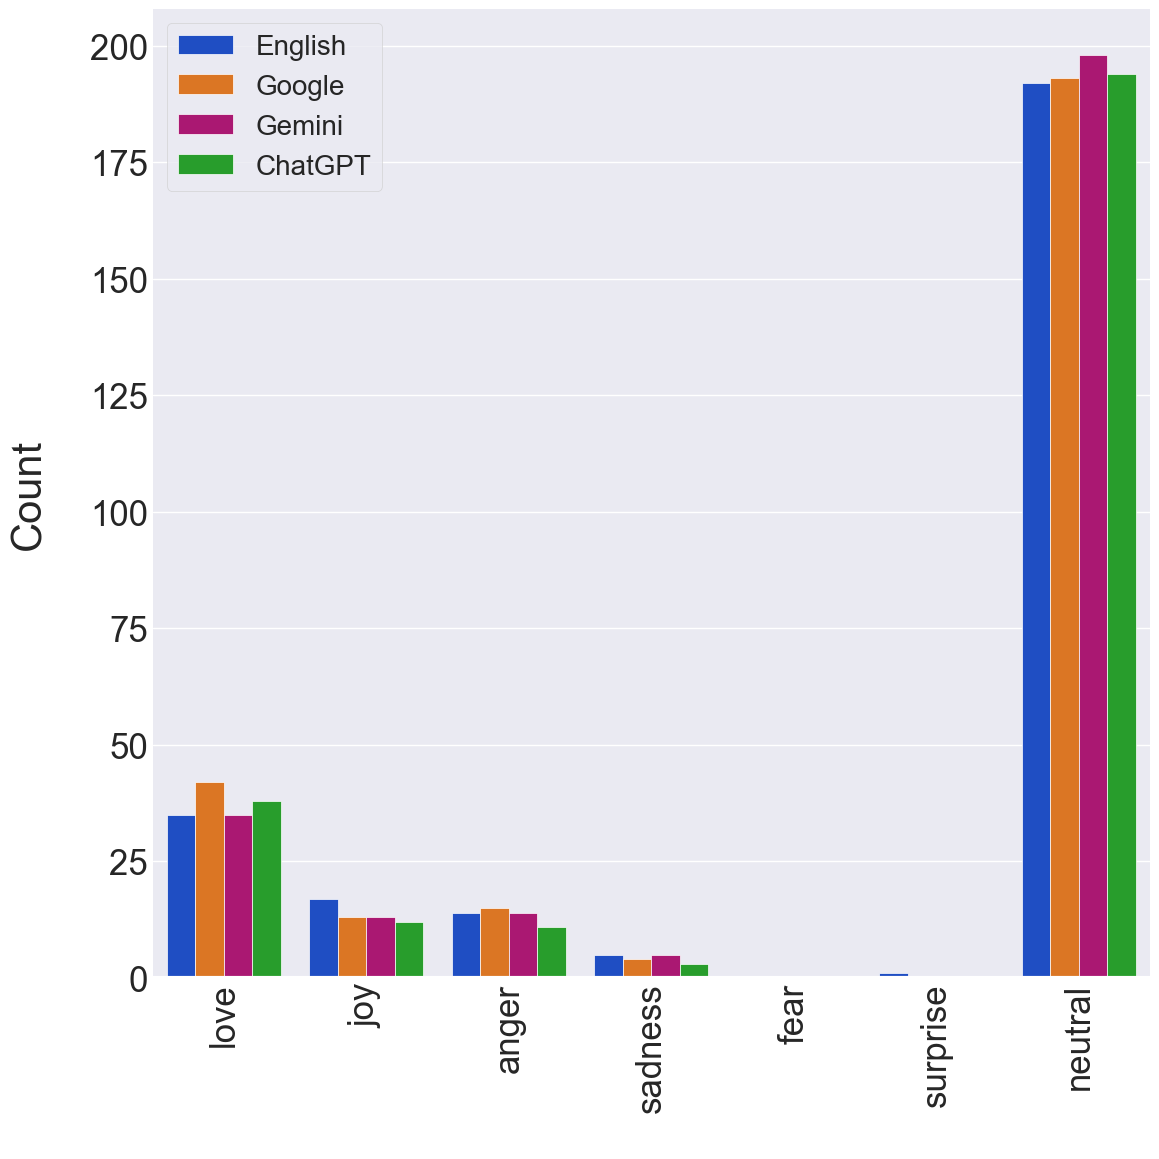

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt
def sentiment_bar(OUTPUT_BASE, SAVEFIG, locate, func):
    output_base = OUTPUT_BASE
    output_graphs = os.path.join(output_base, 'graphs')
    os.makedirs(output_graphs, exist_ok = True)
    
    en_sentiment = func('en/', shaver_classes, OUTPUT_BASE) #ekman_classes
    ggl_sentiment = func('ggl/', shaver_classes, OUTPUT_BASE) #ekman_classes
    gem_sentiment = func('gem/', shaver_classes, OUTPUT_BASE) #ekman_classes
    gpt_sentiment = func('gpt/', shaver_classes, OUTPUT_BASE) #ekman_classes
    
    df_new = pd.concat(
        [
            en_sentiment, 
            ggl_sentiment['Count'], 
            gem_sentiment['Count'], 
            gpt_sentiment['Count'],
        ],
        axis=1
    )
    
    print(df_new)
    
    df_new.columns = ['Sentiment', 'English', 'Google', 'Gemini', 'ChatGPT']
    print(df_new)
    
    df_sentiment_counts = df_new.T.reset_index()
    df_sentiment_counts.columns = df_sentiment_counts.iloc[0, ]
    df_sentiment_counts = df_sentiment_counts.iloc[1:, ].reset_index(drop=True)
    df_sentiment_counts = df_sentiment_counts.rename(columns={'Sentiment': 'Models'})
    
    print(df_sentiment_counts.head())
    print(df_sentiment_counts.columns)
    
    df_new = pd.melt(df_new, id_vars="Sentiment", var_name="Models", value_name="Count")
    print(df_new)
    colors = ["blue", "orange", "magenta", "green"]  
    myPalette = sns.xkcd_palette(colors)
    
    sns.set_style("darkgrid")
    g = sns.catplot(x='Sentiment', y='Count', hue='Models', data=df_new, kind='bar', height=12, palette=myPalette, legend=True, legend_out = False)
    g.despine(left=True)
    ax = g.ax

    sns.move_legend(
        ax,
        loc = locate,
        title = None,
        frameon = True,
        prop = {"size": 20}
    )
    
    ax.set_ylabel('Count', labelpad=30, fontsize=30)
    ax.set_xlabel(' ')
    #plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) #{tick values, add commas for thousands operator, round to 0 decimal places}
    ax.tick_params(axis = "y", labelsize= 25)
    ax.tick_params(axis = "x", labelsize= 25, rotation=90)

    plt.tight_layout()    
    plt.savefig(SAVEFIG, bbox_inches='tight')

sentiment_bar('results/ge_news/sentiment/', 'results/ge_news/sentiment/graphs/sentiment_all_bar.png', 'upper left', all_article_dataframe)

  Sentiment  Count  Count  Count  Count
0      love     35     42     35     38
1       joy     17     13     13     12
2     anger     14     15     14     11
3   sadness      5      4      5      3
4      fear      0      0      0      0
5  surprise      1      0      0      0
  Sentiment  English  Google  Gemini  ChatGPT
0      love       35      42      35       38
1       joy       17      13      13       12
2     anger       14      15      14       11
3   sadness        5       4       5        3
4      fear        0       0       0        0
5  surprise        1       0       0        0
0   Models love joy anger sadness fear surprise
0  English   35  17    14       5    0        1
1   Google   42  13    15       4    0        0
2   Gemini   35  13    14       5    0        0
3  ChatGPT   38  12    11       3    0        0
Index(['Models', 'love', 'joy', 'anger', 'sadness', 'fear', 'surprise'], dtype='object', name=0)
   Sentiment   Models  Count
0       love  English     35
1  

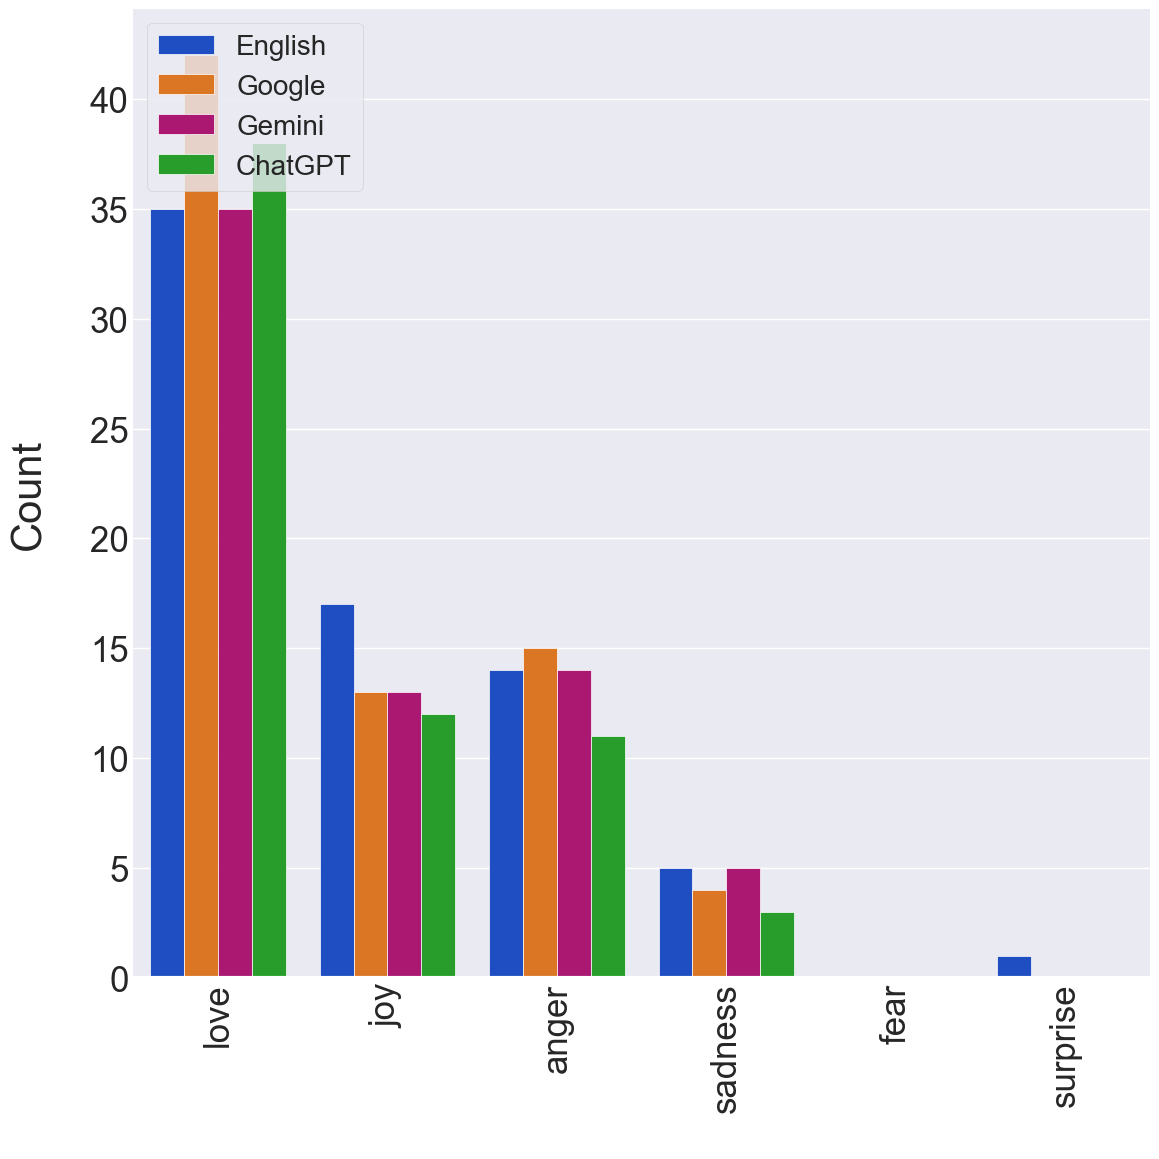

In [101]:
def all_article_dataframe_no_neutral(source, shaver_classes, OUTPUT_BASE): #ekman_classes
    shaver_classes_no_neutral = [ #ekman_classes
        label for label in shaver_classes
        if label != "neutral"
    ]
    
    total_counts = {label: 0 for label in shaver_classes_no_neutral} #ekman_classes
    
    for article in article_names:
        df = pd.read_csv(OUTPUT_BASE + source + article)
        
        if 'text' in df.columns:
            df = df.drop(columns = ['text'])
        
        if 'neutral' in df.columns:
                df = df.drop(columns = ['neutral'])
    
        # sum counts directly (since labels are 0/1)  
        for label in shaver_classes: #ekman_classes
            if label in df.columns:
                total_counts[label] += df[label].sum()

    new_df = pd.DataFrame({
        "Sentiment": list(total_counts.keys()),
        "Count": list(total_counts.values())
    })

    return new_df

sentiment_bar('results/ge_news/sentiment/', 'results/ge_news/sentiment/graphs/sentiment_all_bar_no_neutral.png', 'upper left', all_article_dataframe_no_neutral)

                      Source File  \
0  01_deputy_economy_minister.csv   
1  01_deputy_economy_minister.csv   
2  01_deputy_economy_minister.csv   
3  01_deputy_economy_minister.csv   
4  01_deputy_economy_minister.csv   

                                             Content  
0  ვახტანგ ცინცაძე - აზიის განვითარების ბანკის ან...  
1  აზიის განვითარების ბანკმა აზიის ეკონომიკური პე...  
2  როგორც მინისტრის მოადგილემ აღნიშნა, აზიის განვ...  
3  ვახტანგ ცინცაძის განცხადებით,  2026 წელს აზიის...  
4  „აზიის განვითარების ბანკი ასევე ხაზგასმით აღნი...  
Index(['Source File', 'Content'], dtype='object')
                      Source File  \
0  01_deputy_economy_minister.csv   
1  01_deputy_economy_minister.csv   
2  01_deputy_economy_minister.csv   
3  01_deputy_economy_minister.csv   
4  01_deputy_economy_minister.csv   

                                             Content  
0  Deputy Economy Minister: ADB highlights Georgi...  
1  “The Asian Development Bank (ADB) has publishe...  
2  The De

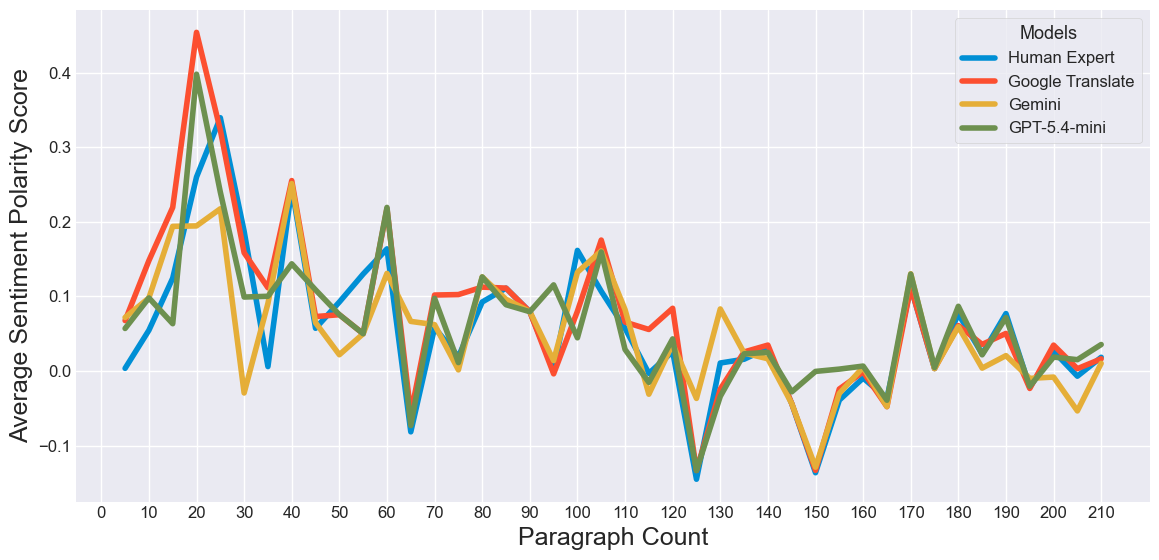

In [102]:
from textblob import TextBlob

df_orig = combine_news(texts_path + "orig/ge_original_1tv_news/combined_all_articles_ge.csv", texts_path + "orig/ge_original_IPN_news/IPN_news_combined_master_ge_renamed.csv")
df_orig.to_csv("Data/Georgian/GeorgianNews/orig/combined_all_articles_ge.csv", index = False)

df_en = combine_news(texts_path + "en/eng_expert_1tv_news/combined_all_articles_eng.csv", texts_path + "en/eng_expert_IPN_news/IPN_news_combined_master_eng_renamed.csv")
df_en.to_csv("Data/Georgian/GeorgianNews/en/combined_all_articles_eng.csv", index = False)

df_gem = combine_news(texts_path + "gem/gem_1tv_news/combined_all_articles_gem.csv", texts_path + "gem/gem_IPN_news/IPN_news_combined_master_gem_renamed.csv")
df_gem.to_csv("Data/Georgian/GeorgianNews/gem/combined_all_articles_gem.csv", index = False)

df_ggl = combine_news(texts_path + "ggl/ggl_1tv_news/combined_all_articles_ggl.csv", texts_path + "ggl/ggl_IPN_news/IPN_news_combined_master_ggl_renamed.csv")
df_ggl.to_csv("Data/Georgian/GeorgianNews/ggl/combined_all_articles_ggl.csv", index = False)

df_gpt = combine_news(texts_path + "gpt/gpt_1tv_news/combined_all_articles_gpt.csv", texts_path + "gpt/gpt_IPN_news/IPN_news_combined_master_gpt_renamed.csv")
df_gpt.to_csv("Data/Georgian/GeorgianNews/gpt/combined_all_articles_gpt.csv", index = False)


file_paths = [
    'Data/Georgian/GeorgianNews/en/combined_all_articles_eng.csv',
    'Data/Georgian/GeorgianNews/ggl/combined_all_articles_ggl.csv',
    'Data/Georgian/GeorgianNews/gem/combined_all_articles_gem.csv',
    'Data/Georgian/GeorgianNews/gpt/combined_all_articles_gpt.csv',
]

labels = ['Human Expert', 'Google Translate', 'Gemini', 'GPT-5.4-mini']

output_path = 'results/ge_news/sentiment/graphs/polarity.png'

def plot_textblob_polarity(file_paths, labels, output_path, NUM_TO_AVG, TICK_INTERVAL):
    plt.figure(figsize=(12, 6))
    for file_path, label in zip(file_paths, labels):
        df = pd.read_csv(file_path)
        if "Translated Content" in df.columns:
            text_column = df["Translated Content"]
        elif "Content" in df.columns:
            text_column = df["Content"]
        elif "text" in df.columns:
            text_column = df["text"]

        text_column = text_column.dropna().astype(str)
        text_column = text_column[text_column.str.strip() != ""]
        
        polarity_scores = [TextBlob(text).sentiment.polarity for text in text_column]
        avg_polarity_scores = []
        x_axis_labels = []
        for i in range(0, len(polarity_scores), NUM_TO_AVG):
            chunk = polarity_scores[i:i + NUM_TO_AVG]
            avg_polarity = np.mean(chunk) if chunk else 0
            avg_polarity_scores.append(avg_polarity)
            x_axis_labels.append(i + NUM_TO_AVG)
        plt.plot(x_axis_labels, avg_polarity_scores, label=label)
    plt.xlabel('Paragraph Count', fontsize=18)
    plt.ylabel('Average Sentiment Polarity Score', fontsize=18)

    max_x = max(x_axis_labels)
    plt.xticks(ticks=range(0, max_x + 1, TICK_INTERVAL), fontsize=12)
    plt.yticks(fontsize=12)

    plt.legend(
        title="Models",
        fontsize=12,
        title_fontsize=13,
        loc="best",
        frameon=True
    )

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_path, format="png", bbox_inches="tight", dpi=300)
    plt.show()

plot_textblob_polarity(file_paths, labels, output_path, 5, 10)

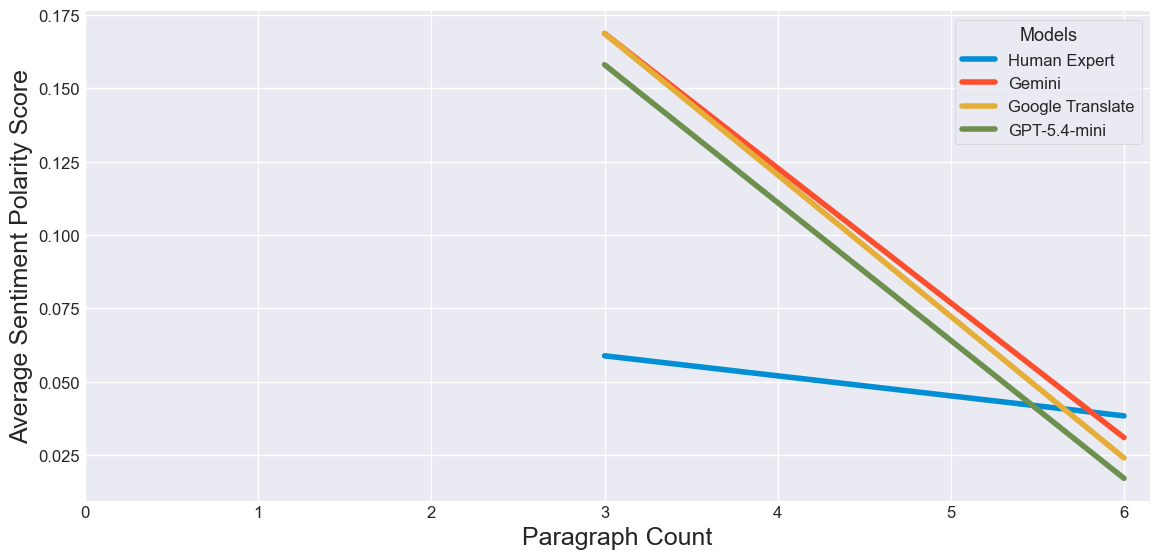

In [103]:
sentiment_files = [
    'results/ge_news/sentiment/en/01_deputy_economy_minister.csv',
    'results/ge_news/sentiment/gem/01_deputy_economy_minister.csv',
    'results/ge_news/sentiment/ggl/01_deputy_economy_minister.csv',
    'results/ge_news/sentiment/gpt/01_deputy_economy_minister.csv',
]

labels = ['Human Expert', 'Gemini', 'Google Translate', 'GPT-5.4-mini']

output_path = 'results/ge_news/sentiment/graphs/polarity_01_deputy_economy_minister.png'

plot_textblob_polarity(sentiment_files, labels, output_path, 3, 1)

In [104]:

def combine_translations(ge_news, ge_poems, bul_prose, bul_news, OUTPUT):
    df_combined_translations = combine_news(ge_news, ge_poems)
    df_bul_prose = pd.read_csv(bul_prose)
    df_combined_translations = pd.concat([df_combined_translations, df_bul_prose], axis = 0)
    df_bul_news = pd.read_csv(bul_news)
    df_combined_translations = pd.concat([df_combined_translations, df_bul_news], axis = 0)
    df_combined_translations.to_csv(OUTPUT, index = False)

INPUT_BASE_ge_news = "Data/Georgian/GeorgianNews/"
INPUT_BASE_ge_poems = "Data/Georgian/Vazha_ThreePoems/"
INPUT_BASE_bul_prose = "Data/Bulgarian/BaiGanyo/"
INPUT_BASE_bul_news = "Data/Bulgarian/BulgarianNews/"
combine_translations(INPUT_BASE_ge_news + "en/combined_all_articles_eng.csv",
                     INPUT_BASE_ge_poems + "en/combined_vazha_poems_en.csv",
                     INPUT_BASE_bul_prose + "en/baiganyo_combined_master_en.csv",
                     INPUT_BASE_bul_news + "en/BTA_news_combined_master_eng.csv",
                     "Data/combined_en.csv")

combine_translations(INPUT_BASE_ge_news + "gem/combined_all_articles_gem.csv",
                     INPUT_BASE_ge_poems + "gem/combined_vazha_poems_gem.csv",
                     INPUT_BASE_bul_prose + "gem/baiganyo_combined_master_gem.csv",
                     INPUT_BASE_bul_news + "gem/BTA_news_combined_master_gem.csv",
                     "Data/combined_gem.csv")

combine_translations(INPUT_BASE_ge_news + "ggl/combined_all_articles_ggl.csv", 
                     INPUT_BASE_ge_poems + "ggl/combined_vazha_poems_ggl.csv", 
                     INPUT_BASE_bul_prose + "ggl/baiganyo_combined_master_ggl.csv", 
                     INPUT_BASE_bul_news + "ggl/BTA_news_combined_master_ggl.csv",
                     "Data/combined_ggl.csv")

combine_translations(INPUT_BASE_ge_news + "gpt/combined_all_articles_gpt.csv", 
                     INPUT_BASE_ge_poems + "gpt/combined_vazha_poems_gpt.csv", 
                     INPUT_BASE_bul_prose + "gpt/baiganyo_combined_master_gpt.csv", 
                     INPUT_BASE_bul_news + "gpt/BTA_news_combined_master_gpt.csv",
                     "Data/combined_gpt.csv")

                      Source File  \
0  01_deputy_economy_minister.csv   
1  01_deputy_economy_minister.csv   
2  01_deputy_economy_minister.csv   
3  01_deputy_economy_minister.csv   
4  01_deputy_economy_minister.csv   

                                             Content  
0  Deputy Economy Minister: ADB highlights Georgi...  
1  “The Asian Development Bank (ADB) has publishe...  
2  The Deputy Minister noted that the report draw...  
3  For 2026, the ADB expects average inflation in...  
4  “The Asian Development Bank also emphasises th...  
Index(['Source File', 'Content'], dtype='object')
                      Source File  \
0  01_deputy_economy_minister.csv   
1  01_deputy_economy_minister.csv   
2  01_deputy_economy_minister.csv   
3  01_deputy_economy_minister.csv   
4  01_deputy_economy_minister.csv   

                                             Content  \
0  ვახტანგ ცინცაძე - აზიის განვითარების ბანკის ან...   
1  აზიის განვითარების ბანკმა აზიის ეკონომიკური პე...   
2  როგ

In [105]:
def mean_textblob_polarity(file_paths, labels):
    results = []
    for file_path, label in zip(file_paths, labels):
        df = pd.read_csv(file_path)
        if "Translated Content" in df.columns:
            text_column = df["Translated Content"]
        elif "Content" in df.columns:
            text_column = df["Content"]
        elif "text" in df.columns:
            text_column = df["text"]

        text_column = text_column.dropna().astype(str)
        text_column = text_column[text_column.str.strip() != ""]
        
        polarity_scores = [TextBlob(text).sentiment.polarity for text in text_column]
        mean_polarity_scores = np.mean(polarity_scores)
        sd_polarity_scores = np.std(polarity_scores, ddof = 1)
        results.append({
            "Model": label, 
            "Mean": round(mean_polarity_scores, 3),
            "Standard Deviation": round(sd_polarity_scores, 3)
        })

    results_df = pd.DataFrame(results)
    results_df.to_csv("results/mean_polarity_models.csv", index = False)
    return results_df

In [106]:
#Mean polarity over Georgian and Bulgarian texts
file_paths = [
    "Data/combined_en.csv",
    "Data/combined_ggl.csv",
    "Data/combined_gem.csv",
    "Data/combined_gpt.csv",
]

labels = [
    'Human Expert',
    'Google Translate',
    'Gemini',
    'GPT-5.4-mini'
]

mean_textblob_polarity(file_paths, labels)

,Model,Mean,Standard Deviation
0,Human Expert,0.054,0.223
1,Google Translate,0.057,0.231
2,Gemini,0.070,0.217
3,GPT-5.4-mini,0.062,0.212


In [107]:
def combine_translations_one_lang(news, text, OUTPUT):
    df_combined_translations = combine_news(news, text)
    df_combined_translations.to_csv(OUTPUT, index = False)

INPUT_BASE_ge_news = "Data/Georgian/GeorgianNews/"
INPUT_BASE_ge_poems = "Data/Georgian/Vazha_ThreePoems/"
INPUT_BASE_bul_prose = "Data/Bulgarian/BaiGanyo/"
INPUT_BASE_bul_news = "Data/Bulgarian/BulgarianNews/"
OUTPUT_BASE_ge = "Data/combined_translations_ge/"
OUTPUT_BASE_bul = "Data/combined_translations_bul/"

combine_translations_one_lang(INPUT_BASE_ge_news + "en/combined_all_articles_eng.csv",
                     INPUT_BASE_ge_poems + "en/combined_vazha_poems_en.csv",
                     OUTPUT_BASE_ge + "combined_ge_en.csv")

combine_translations_one_lang(INPUT_BASE_bul_prose + "en/baiganyo_combined_master_en.csv",
                     INPUT_BASE_bul_news + "en/BTA_news_combined_master_eng.csv",
                     OUTPUT_BASE_bul + "combined_bul_en.csv")

combine_translations_one_lang(INPUT_BASE_ge_news + "gem/combined_all_articles_gem.csv",
                     INPUT_BASE_ge_poems + "gem/combined_vazha_poems_gem.csv",
                     OUTPUT_BASE_ge + "combined_ge_gem.csv")

combine_translations_one_lang(INPUT_BASE_bul_prose + "gem/baiganyo_combined_master_gem.csv",
                     INPUT_BASE_bul_news + "gem/BTA_news_combined_master_gem.csv",
                     OUTPUT_BASE_bul + "combined_bul_gem.csv")

combine_translations_one_lang(INPUT_BASE_ge_news + "ggl/combined_all_articles_ggl.csv", 
                     INPUT_BASE_ge_poems + "ggl/combined_vazha_poems_ggl.csv",
                     OUTPUT_BASE_ge + "combined_ge_ggl.csv")

combine_translations_one_lang(INPUT_BASE_bul_prose + "ggl/baiganyo_combined_master_ggl.csv", 
                     INPUT_BASE_bul_news + "ggl/BTA_news_combined_master_ggl.csv",
                     OUTPUT_BASE_bul + "combined_bul_ggl.csv")

combine_translations_one_lang(INPUT_BASE_ge_news + "gpt/combined_all_articles_gpt.csv", 
                     INPUT_BASE_ge_poems + "gpt/combined_vazha_poems_gpt.csv",
                     OUTPUT_BASE_ge + "combined_ge_gpt.csv")

combine_translations_one_lang(INPUT_BASE_bul_prose + "gpt/baiganyo_combined_master_gpt.csv", 
                     INPUT_BASE_bul_news + "gpt/BTA_news_combined_master_gpt.csv",
                     OUTPUT_BASE_bul + "combined_bul_gpt.csv")

                      Source File  \
0  01_deputy_economy_minister.csv   
1  01_deputy_economy_minister.csv   
2  01_deputy_economy_minister.csv   
3  01_deputy_economy_minister.csv   
4  01_deputy_economy_minister.csv   

                                             Content  
0  Deputy Economy Minister: ADB highlights Georgi...  
1  “The Asian Development Bank (ADB) has publishe...  
2  The Deputy Minister noted that the report draw...  
3  For 2026, the ADB expects average inflation in...  
4  “The Asian Development Bank also emphasises th...  
Index(['Source File', 'Content'], dtype='object')
                                  Source File  \
0  00_bai_ganyo_starts_out_for_europe_bul.csv   
1  00_bai_ganyo_starts_out_for_europe_bul.csv   
2  00_bai_ganyo_starts_out_for_europe_bul.csv   
3  00_bai_ganyo_starts_out_for_europe_bul.csv   
4  00_bai_ganyo_starts_out_for_europe_bul.csv   

                                             Content  
0  They helped Bai Ganyo slough off his heavy, 

In [108]:
#Mean polarity over Georgian texts
file_paths = [
    OUTPUT_BASE_ge + "combined_ge_en.csv",
    OUTPUT_BASE_ge + "combined_ge_ggl.csv",
    OUTPUT_BASE_ge + "combined_ge_gem.csv",
    OUTPUT_BASE_ge + "combined_ge_gpt.csv",
]

labels = [
    'Human Expert',
    'Google Translate',
    'Gemini',
    'GPT-5.4-mini'
]

mean_textblob_polarity(file_paths, labels)


,Model,Mean,Standard Deviation
0,Human Expert,0.027,0.196
1,Google Translate,0.049,0.220
2,Gemini,0.056,0.209
3,GPT-5.4-mini,0.054,0.212


In [109]:
file_paths = [
    OUTPUT_BASE_bul + "combined_bul_en.csv",
    OUTPUT_BASE_bul + "combined_bul_ggl.csv",
    OUTPUT_BASE_bul + "combined_bul_gem.csv",
    OUTPUT_BASE_bul + "combined_bul_gpt.csv",
]

labels = [
    'Human Expert',
    'Google Translate',
    'Gemini',
    'GPT-5.4-mini'
]

mean_textblob_polarity(file_paths, labels)

,Model,Mean,Standard Deviation
0,Human Expert,0.065,0.234
1,Google Translate,0.061,0.235
2,Gemini,0.076,0.220
3,GPT-5.4-mini,0.065,0.212


In [110]:
%matplotlib inline
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

In [111]:
import re
import gensim 
import nltk
from nltk.corpus import stopwords

stop_words = stopwords.words('english')
newStopWords = []
stop_words.extend(newStopWords)


def remove_stopwords(texts):
    return [[word for word in gensim.utils.simple_preprocess(str(text)) if word not in stop_words] for text in texts]
    #list without stopwords

def tokenize(texts):
    for text in texts:
        yield(gensim.utils.simple_preprocess(str(text), deacc=True))
        #tokenized, without punctuation, accents

def preprocessing(df):
    df = df.copy()
    df['text'] = df['text'].str.lower()                                                      # Convert to lowercase
    df['text'] = df['text'].str.replace(r'[^a-zA-Z#]', ' ', regex=True) #     # keep letters and spaces only
    df['text'] = df['text'].apply(lambda x:' '.join([w for w in x.split() if len(w)>2]))     # Remove short words
    df['tokens'] = list(tokenize(df['text']))
    df['tokens_no_stop'] = remove_stopwords(df['text'])
    df['tokens_no_stop_joined'] = df['tokens_no_stop'].apply(lambda x: ' '.join(x) )
    
    return df

def retrieve_text(df):
    doc = '. '.join(df['tokens_no_stop_joined'])
    return doc

def ngrams_series_func(data, n):
    wordList = re.sub("[^\w]", " ",  data).split() #replace non-words with spaces
    ngrams_series = (pd.Series(nltk.ngrams(wordList, n)).value_counts())[:5] #top 5 most frequent
    return ngrams_series

In [112]:
from matplotlib import cm
from matplotlib.ticker import FuncFormatter

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
barcolors = ['#87B88C','#9ED2A1','#E7E8CB','#48A0C9','#2A58A1','#2E8B55','#DF3659','Grey']
barstyle = {"edgecolor":"black", "linewidth": 1}

In [113]:
def topic(source, OUTPUT_BASE, article_names):
    topic_df = pd.read_csv(OUTPUT_BASE + source + article_names[0])

    #print(topic_df)
    
    for article in article_names[1:]:
        df = pd.read_csv(OUTPUT_BASE + source + article) #'results_bul/news/sentiment/'
        topic_df = pd.concat([topic_df, df], axis=0, ignore_index=True)
    
    return topic_df

In [114]:
from matplotlib.ticker import MaxNLocator

def ngrams_graphs(text, translation, OUTPUT_BASE):  
    output_ngrams = os.path.join(output_graphs, 'ngrams')
    os.makedirs(output_ngrams, exist_ok = True)
    
    bigram1 = ngrams_series_func(text, 2)
    trigram1 = ngrams_series_func(text, 3)
    ngram1 = pd.concat([bigram1, trigram1])
    
    plt.rcParams.update({'font.size': 20})
    fig, ax=plt.subplots(1,1, figsize=(8,4))
    
    barh_ax = ax
    
    ngram1[::-1].plot.barh(ax=barh_ax, color='magenta', **barstyle)
    barh_ax.yaxis.set_label_position("left")
    barh_ax.xaxis.tick_top()
    barh_ax.xaxis.set_label_position("bottom")
    barh_ax.set_xlim(barh_ax.get_xlim()[::-1])
    barh_ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    barh_ax.set_xlabel(translation)
    barh_ax.set_ylabel('', fontsize=50)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_BASE}graphs/ngrams/{translation}.png', facecolor='white')


In [120]:
#Georgian News
OUTPUT_BASE = "results/ge_news/sentiment/"
topic_df = topic('en/', OUTPUT_BASE, article_names)
print(topic_df["text"].isna().sum())
print(topic_df[topic_df["text"].isna()].head(20))

topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

output_graphs = os.path.join(OUTPUT_BASE, 'graphs')
os.makedirs(output_graphs, exist_ok = True)
ngrams_graphs(text, 'English', OUTPUT_BASE)

topic_df = topic('ggl/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Google', OUTPUT_BASE)

topic_df = topic('gem/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Gemini', OUTPUT_BASE)

topic_df = topic('gpt/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'ChatGPT', OUTPUT_BASE)

0
Empty DataFrame
Columns: [text, love, joy, anger, sadness, fear, surprise, neutral]
Index: []


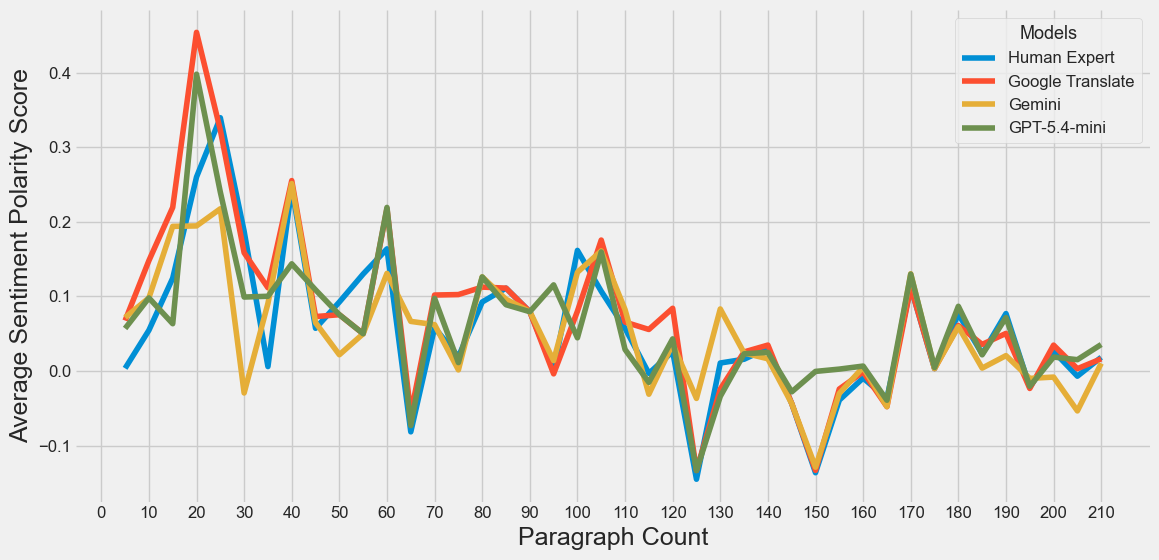

In [121]:
file_paths = [
    'Data/Georgian/GeorgianNews/en/combined_all_articles_eng.csv',
    'Data/Georgian/GeorgianNews/ggl/combined_all_articles_ggl.csv',
    'Data/Georgian/GeorgianNews/gem/combined_all_articles_gem.csv',
    'Data/Georgian/GeorgianNews/gpt/combined_all_articles_gpt.csv',
]

labels = ['Human Expert', 'Google Translate', 'Gemini', 'GPT-5.4-mini']

output_path = 'results/ge_news/sentiment/graphs/polarity.png'

plot_textblob_polarity(file_paths, labels, output_path, 5, 10)

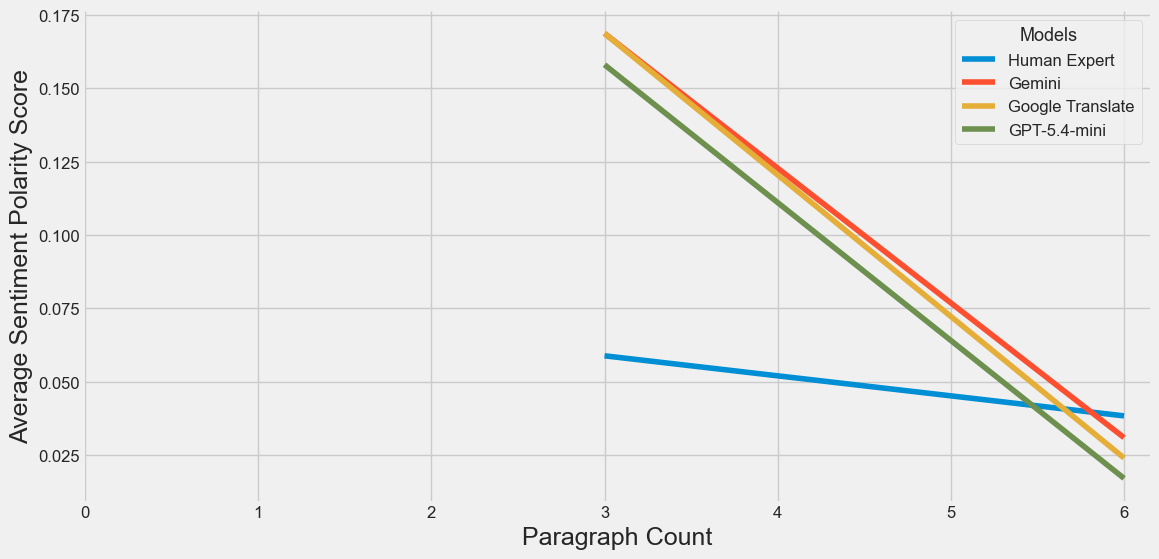

In [122]:
sentiment_files = [
    'results/ge_news/sentiment/en/01_deputy_economy_minister.csv',
    'results/ge_news/sentiment/gem/01_deputy_economy_minister.csv',
    'results/ge_news/sentiment/ggl/01_deputy_economy_minister.csv',
    'results/ge_news/sentiment/gpt/01_deputy_economy_minister.csv',
]

labels = ['Human Expert', 'Gemini', 'Google Translate', 'GPT-5.4-mini']

output_path = 'results/ge_news/sentiment/graphs/polarity_01_deputy_economy_minister.png'

plot_textblob_polarity(sentiment_files, labels, output_path, 3, 1)

In [123]:
#Bulgarian News

texts_path = 'Data/Bulgarian/BulgarianNews/'
#ge_1tv_csv = texts_path + "ge/ge_original_1tv_news/combined_all_articles_ge.csv"
#ge_IPN_csv = texts_path + "ge/ge_original_IPN_news/IPN_news_combined_master_ge_renamed.csv"

#df_1tv_ge = pd.read_csv(ge_1tv_csv)
#df_IPN_ge = pd.read_csv(ge_IPN_csv)

#df_ge = pd.concat([df_1tv_ge, df_IPN_ge], axis = 0)
#print(df_ge.head())
#print(df_ge.columns)

In [124]:
file_paths = ["orig/BTA_news_combined_master_bul.csv", 
              "en/BTA_news_combined_master_eng.csv",
              "gem/BTA_news_combined_master_gem.csv",
              "ggl/BTA_news_combined_master_ggl.csv",
              "gpt/BTA_news_combined_master_gpt.csv"]

OUTPUT_BASE = 'results/bul_news/sentiment/'

def text_name(texts_path, file_paths):
    sources = ['orig/', 'en/', 'ggl/', 'gem/', 'gpt/']
    df_orig = pd.read_csv(texts_path + file_paths[0])
    df_en = pd.read_csv(texts_path + file_paths[1])
    df_gem = pd.read_csv(texts_path + file_paths[2])
    df_ggl = pd.read_csv(texts_path + file_paths[3])
    df_gpt = pd.read_csv(texts_path + file_paths[4])
    article_names = sorted(df_orig["Source File"].unique())
    print(article_names)
    print(len(article_names))
    return article_names, df_orig, df_en, df_ggl, df_gem, df_gpt

article_names, df_orig, df_en, df_ggl, df_gem, df_gpt = text_name(texts_path, file_paths)
text_df(OUTPUT_BASE, article_names, df_orig, df_en, df_ggl, df_gem, df_gpt)


['01_bul_Political_Forces.csv', '02_bul_Bulgarian_Airline.csv', '03_bul_Bulgarian_Cultural.csv', '04_bul_Bulgaria_Driving.csv', '05_bul_Bulgarian_Deputy.csv', '06_bul_Patriarch_Daniil.csv', '07_bul_Mexico_Festival.csv', '08_bul_Bulgaria_Submits.csv', '09_bul_Dispute_Erupts.csv']
9
Saved: results/bul_news/sentiment/orig/01_bul_Political_Forces.csv
Saved: results/bul_news/sentiment/orig/02_bul_Bulgarian_Airline.csv
Saved: results/bul_news/sentiment/orig/03_bul_Bulgarian_Cultural.csv
Saved: results/bul_news/sentiment/orig/04_bul_Bulgaria_Driving.csv
Saved: results/bul_news/sentiment/orig/05_bul_Bulgarian_Deputy.csv
Saved: results/bul_news/sentiment/orig/06_bul_Patriarch_Daniil.csv
Saved: results/bul_news/sentiment/orig/07_bul_Mexico_Festival.csv
Saved: results/bul_news/sentiment/orig/08_bul_Bulgaria_Submits.csv
Saved: results/bul_news/sentiment/orig/09_bul_Dispute_Erupts.csv
Saved: results/bul_news/sentiment/en/01_bul_Political_Forces.csv
Saved: results/bul_news/sentiment/en/02_bul_Bulgar

  Sentiment  Count  Count  Count  Count
0      love     42     49     46     47
1       joy      3      2      2      2
2     anger      1      1      2      2
3   sadness      0      0      0      0
4      fear      0      0      0      0
5  surprise      0      0      0      0
6   neutral     68     63     68     67
  Sentiment  English  Google  Gemini  ChatGPT
0      love       42      49      46       47
1       joy        3       2       2        2
2     anger        1       1       2        2
3   sadness        0       0       0        0
4      fear        0       0       0        0
5  surprise        0       0       0        0
6   neutral       68      63      68       67
0   Models love joy anger sadness fear surprise neutral
0  English   42   3     1       0    0        0      68
1   Google   49   2     1       0    0        0      63
2   Gemini   46   2     2       0    0        0      68
3  ChatGPT   47   2     2       0    0        0      67
Index(['Models', 'love', 'joy', 

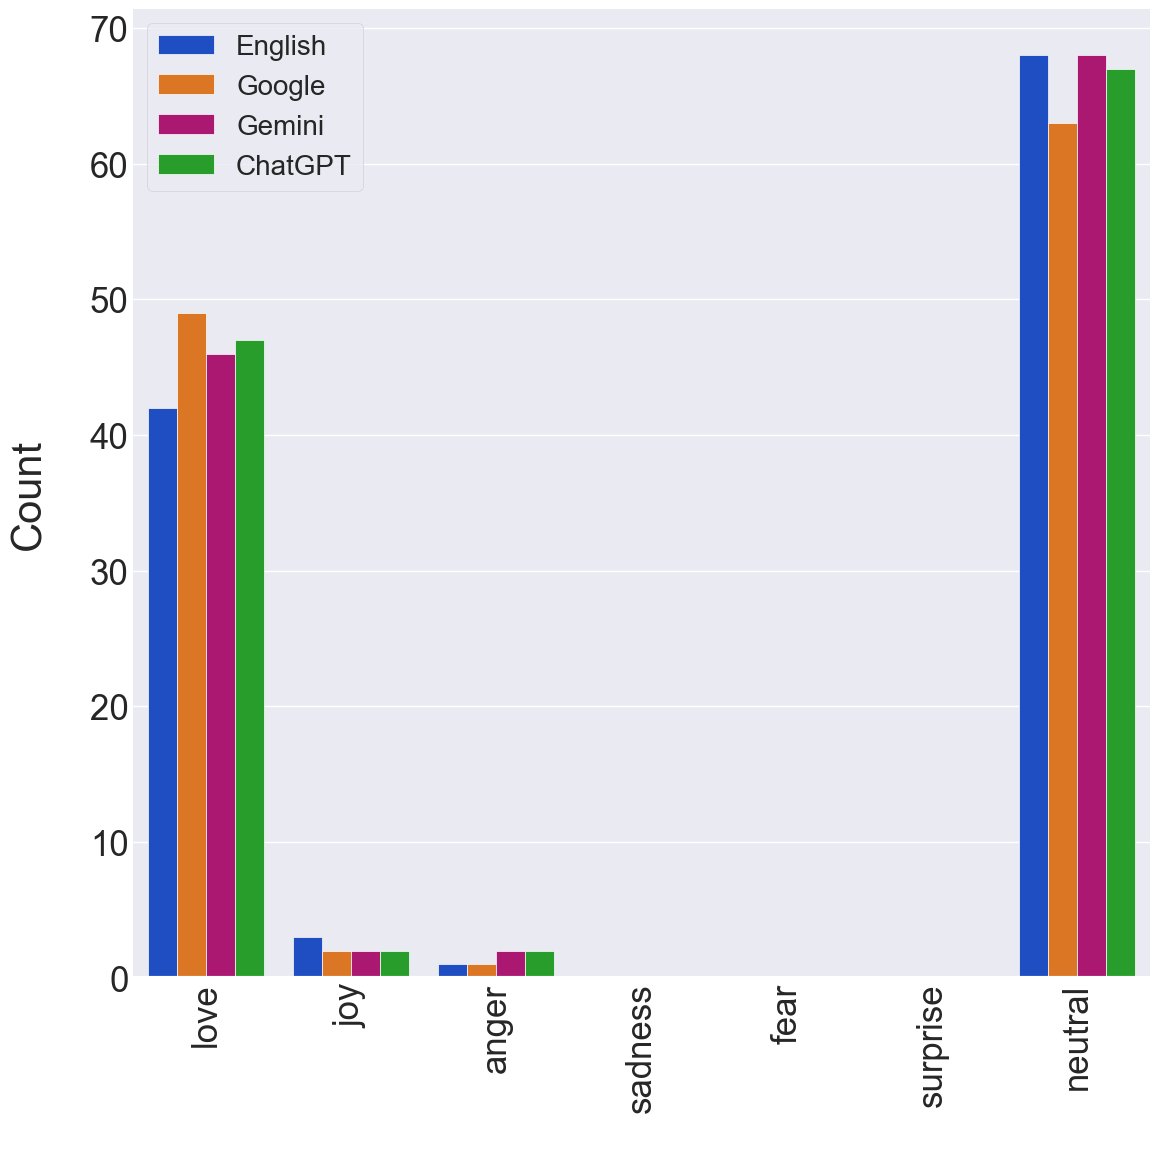

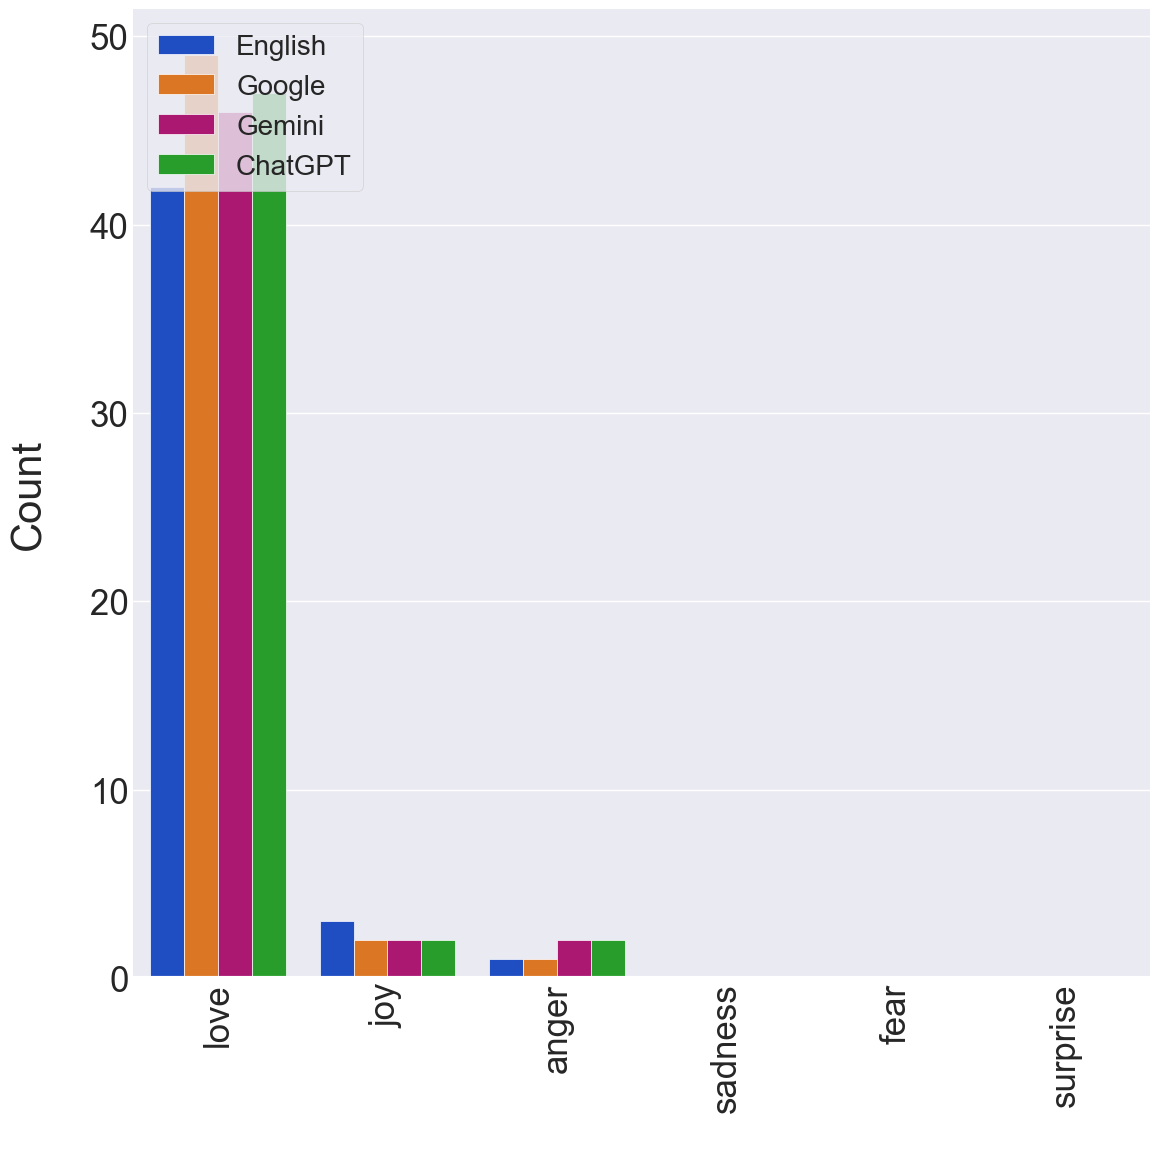

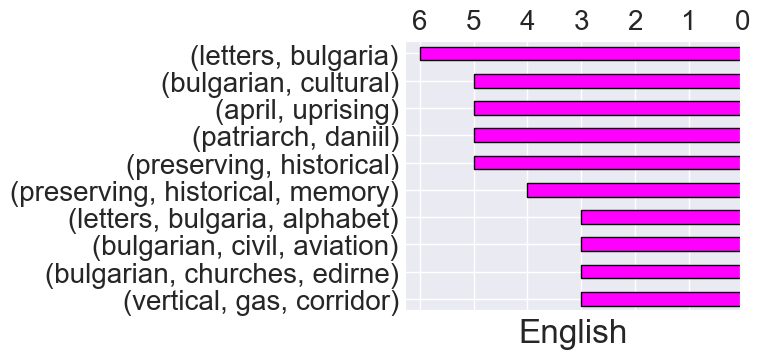

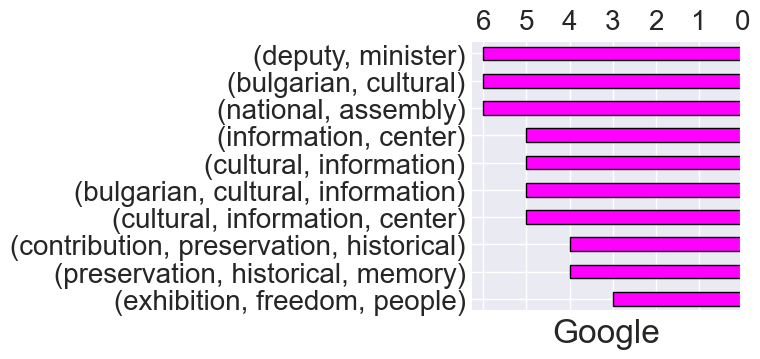

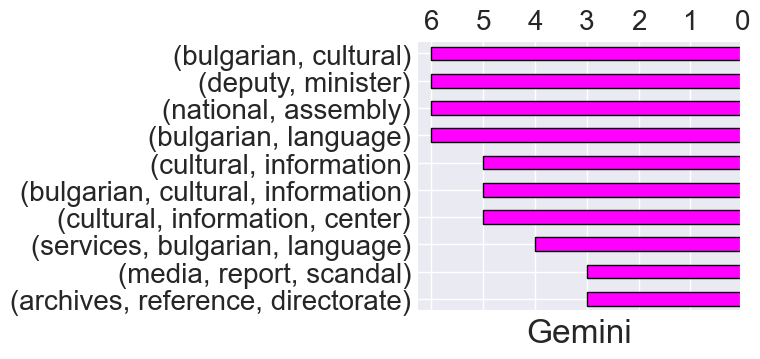

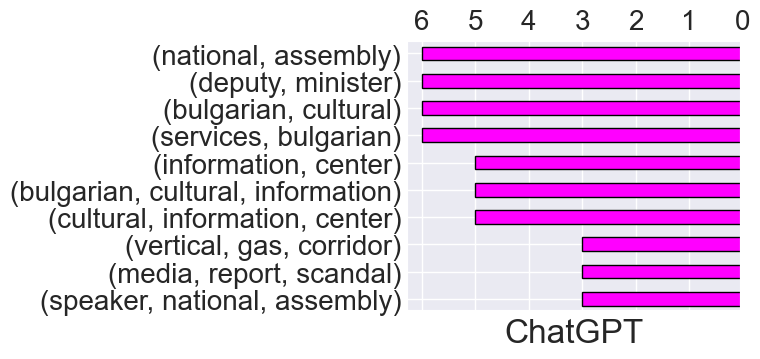

In [125]:
sentiment_bar(OUTPUT_BASE, 'results/bul_news/sentiment/graphs/sentiment_all_bar.png', 'upper left', all_article_dataframe)
sentiment_bar(OUTPUT_BASE, 'results/bul_news/sentiment/graphs/sentiment_all_bar.png', 'upper left', all_article_dataframe_no_neutral)

topic_df = topic('en/', OUTPUT_BASE, article_names) 
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

output_graphs = os.path.join(OUTPUT_BASE, 'graphs')
os.makedirs(output_graphs, exist_ok = True)
    
ngrams_graphs(text, 'English', OUTPUT_BASE)

topic_df = topic('ggl/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Google', OUTPUT_BASE)

topic_df = topic('gem/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Gemini', OUTPUT_BASE)

topic_df = topic('gpt/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'ChatGPT', OUTPUT_BASE)

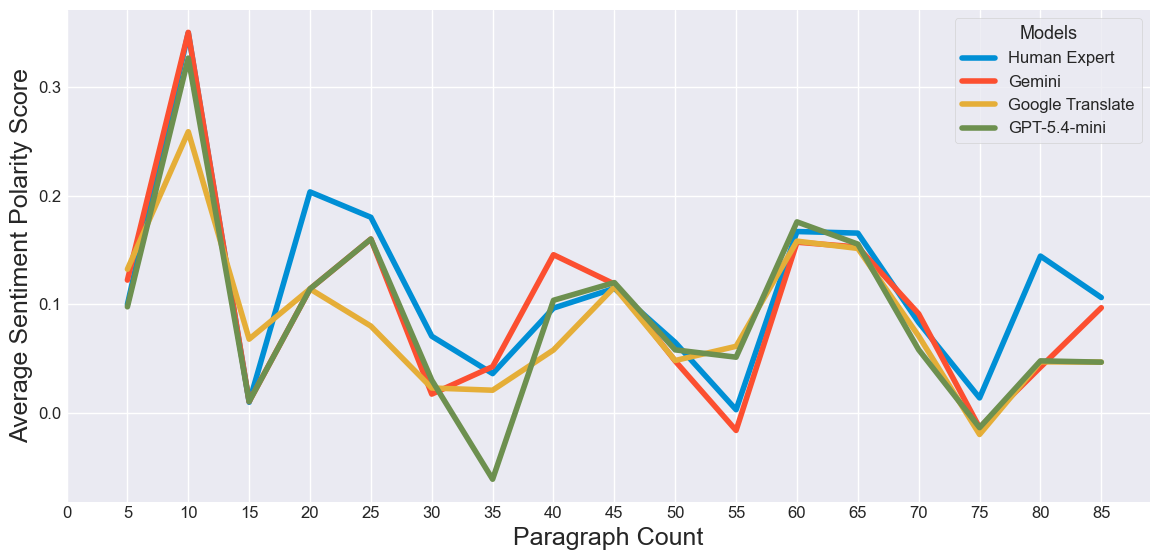

In [126]:
file_paths = [
    'Data/Bulgarian/BulgarianNews/en/BTA_news_combined_master_eng.csv',
    'Data/Bulgarian/BulgarianNews/gem/BTA_news_combined_master_gem.csv',
    'Data/Bulgarian/BulgarianNews/ggl/BTA_news_combined_master_ggl.csv',
    'Data/Bulgarian/BulgarianNews/gpt/BTA_news_combined_master_gpt.csv',
]

labels = ['Human Expert', 'Gemini', 'Google Translate','GPT-5.4-mini']

output_path = 'results/bul_news/sentiment/graphs/polarity.png'
plot_textblob_polarity(file_paths, labels, output_path, 5, 5)

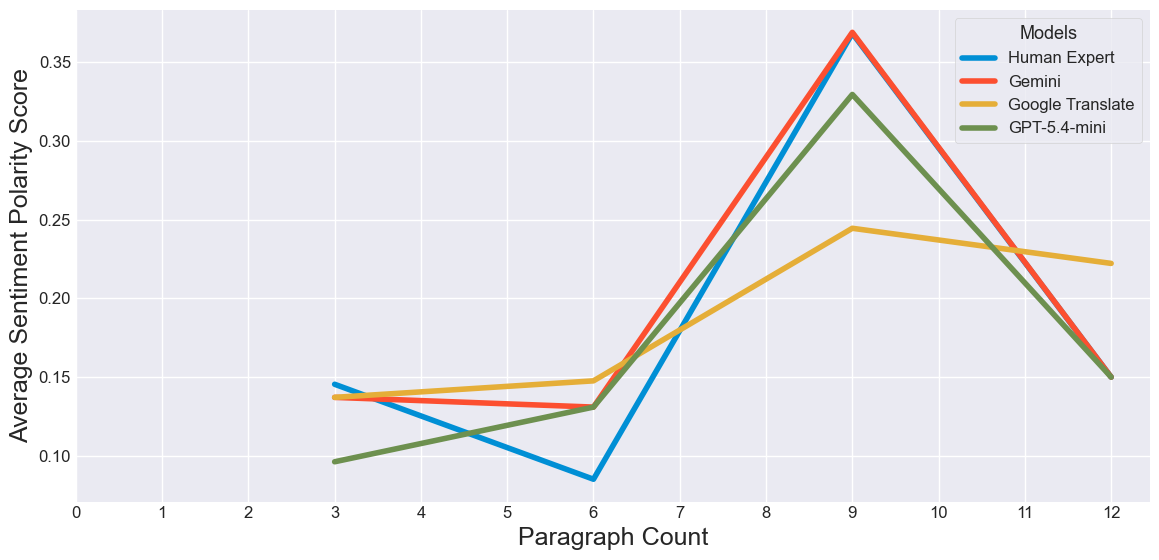

In [127]:
sentiment_files = [
    'results/bul_news/sentiment/en/01_bul_Political_Forces.csv',
    'results/bul_news/sentiment/gem/01_bul_Political_Forces.csv',
    'results/bul_news/sentiment/ggl/01_bul_Political_Forces.csv',
    'results/bul_news/sentiment/gpt/01_bul_Political_Forces.csv',
]

labels = ['Human Expert', 'Gemini', 'Google Translate', 'GPT-5.4-mini']

output_path = 'results/bul_news/sentiment/graphs/polarity_01_bul_Political_Forces.png'

plot_textblob_polarity(sentiment_files, labels, output_path, 3, 1)

In [128]:
#Georgian poems

texts_path = 'Data/Georgian/Vazha_ThreePoems/'

In [129]:
file_paths = ["orig/combined_vazha_poems_ge.csv", 
              "en/combined_vazha_poems_en.csv",
              "gem/combined_vazha_poems_gem.csv",
              "ggl/combined_vazha_poems_ggl.csv",
              "gpt/combined_vazha_poems_gpt.csv"]

OUTPUT_BASE = 'results/ge_poems/sentiment/'

article_names, df_orig, df_en, df_ggl, df_gem, df_gpt = text_name(texts_path, file_paths)
text_df(OUTPUT_BASE, article_names, df_orig, df_en, df_ggl, df_gem, df_gpt)

['01_aluda_ketelauri_ge.csv', '02_host_and_guest_ge.csv', '03_the_snake_eater_ge.csv']
3
Saved: results/ge_poems/sentiment/orig/01_aluda_ketelauri_ge.csv
Saved: results/ge_poems/sentiment/orig/02_host_and_guest_ge.csv
Saved: results/ge_poems/sentiment/orig/03_the_snake_eater_ge.csv
Saved: results/ge_poems/sentiment/en/01_aluda_ketelauri_ge.csv
Saved: results/ge_poems/sentiment/en/02_host_and_guest_ge.csv
Saved: results/ge_poems/sentiment/en/03_the_snake_eater_ge.csv
Saved: results/ge_poems/sentiment/ggl/01_aluda_ketelauri_ge.csv
Saved: results/ge_poems/sentiment/ggl/02_host_and_guest_ge.csv
Saved: results/ge_poems/sentiment/ggl/03_the_snake_eater_ge.csv
Saved: results/ge_poems/sentiment/gem/01_aluda_ketelauri_ge.csv
Saved: results/ge_poems/sentiment/gem/02_host_and_guest_ge.csv
Saved: results/ge_poems/sentiment/gem/03_the_snake_eater_ge.csv
Saved: results/ge_poems/sentiment/gpt/01_aluda_ketelauri_ge.csv
Saved: results/ge_poems/sentiment/gpt/02_host_and_guest_ge.csv
Saved: results/ge_po

  Sentiment  Count  Count  Count  Count
0      love     30     32     34     28
1       joy     23     40     37     41
2     anger     22     25     25     26
3   sadness     20     15     20     21
4      fear      4      3      4      4
5  surprise      7     11      8      8
6   neutral    197    171    185    186
  Sentiment  English  Google  Gemini  ChatGPT
0      love       30      32      34       28
1       joy       23      40      37       41
2     anger       22      25      25       26
3   sadness       20      15      20       21
4      fear        4       3       4        4
5  surprise        7      11       8        8
6   neutral      197     171     185      186
0   Models love joy anger sadness fear surprise neutral
0  English   30  23    22      20    4        7     197
1   Google   32  40    25      15    3       11     171
2   Gemini   34  37    25      20    4        8     185
3  ChatGPT   28  41    26      21    4        8     186
Index(['Models', 'love', 'joy', 

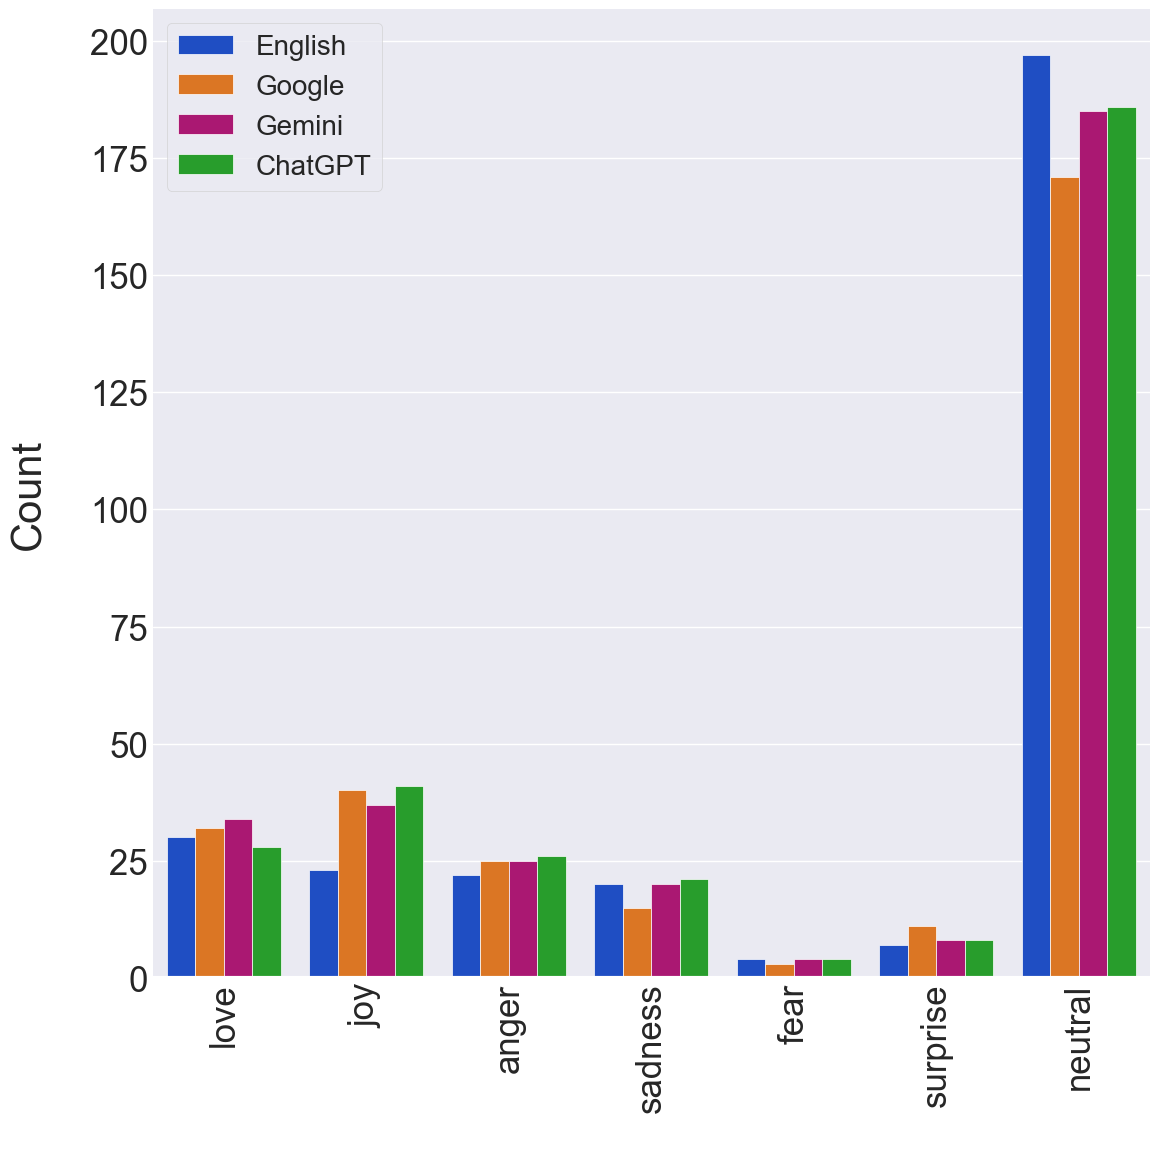

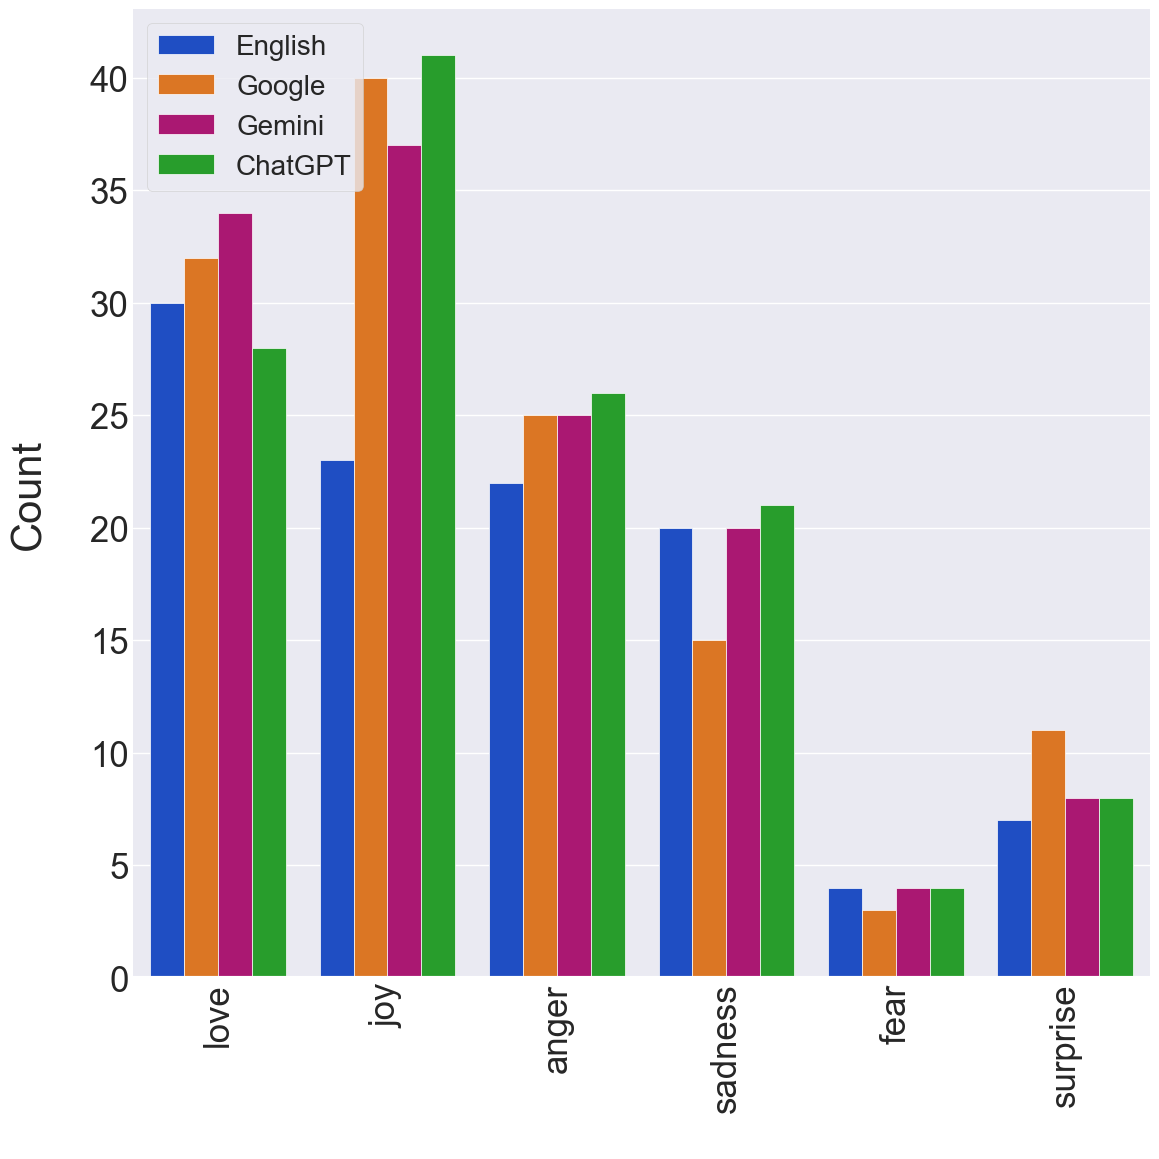

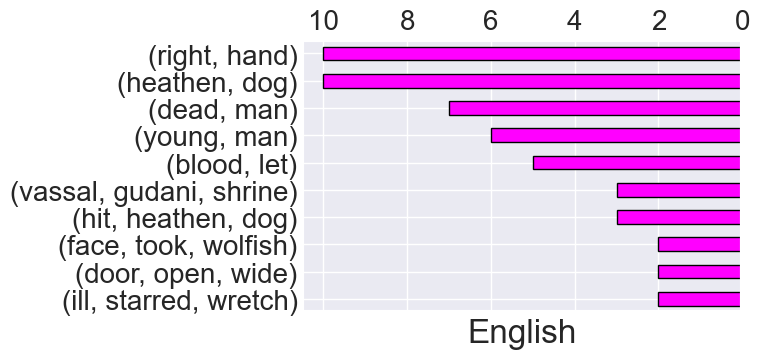

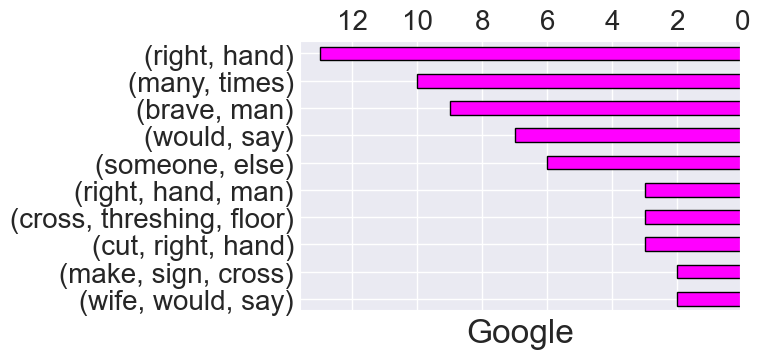

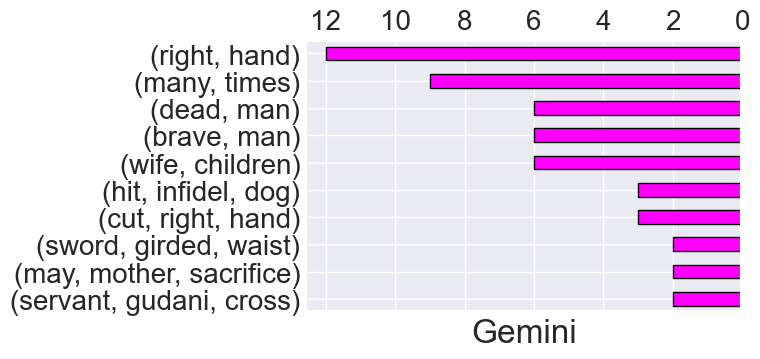

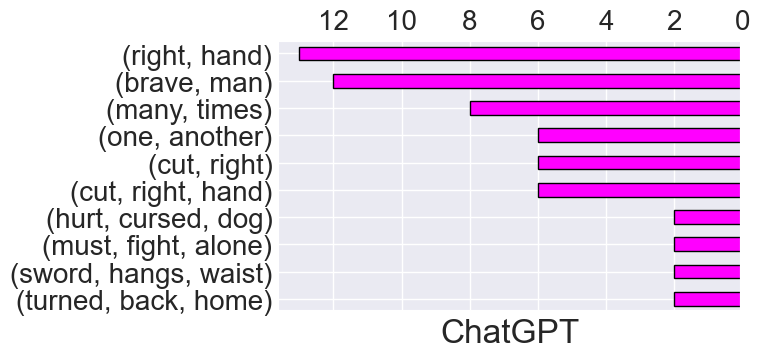

In [130]:
sentiment_bar(OUTPUT_BASE, 'results/ge_poems/sentiment/graphs/sentiment_all_bar.png', 'upper left', all_article_dataframe)
sentiment_bar(OUTPUT_BASE, 'results/ge_poems/sentiment/graphs/sentiment_all_bar.png', 'upper left', all_article_dataframe_no_neutral)

topic_df = topic('en/', OUTPUT_BASE, article_names) 
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

output_graphs = os.path.join(OUTPUT_BASE, 'graphs')
os.makedirs(output_graphs, exist_ok = True)
    
ngrams_graphs(text, 'English', OUTPUT_BASE)

topic_df = topic('ggl/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Google', OUTPUT_BASE)

topic_df = topic('gem/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Gemini', OUTPUT_BASE)

topic_df = topic('gpt/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'ChatGPT', OUTPUT_BASE)

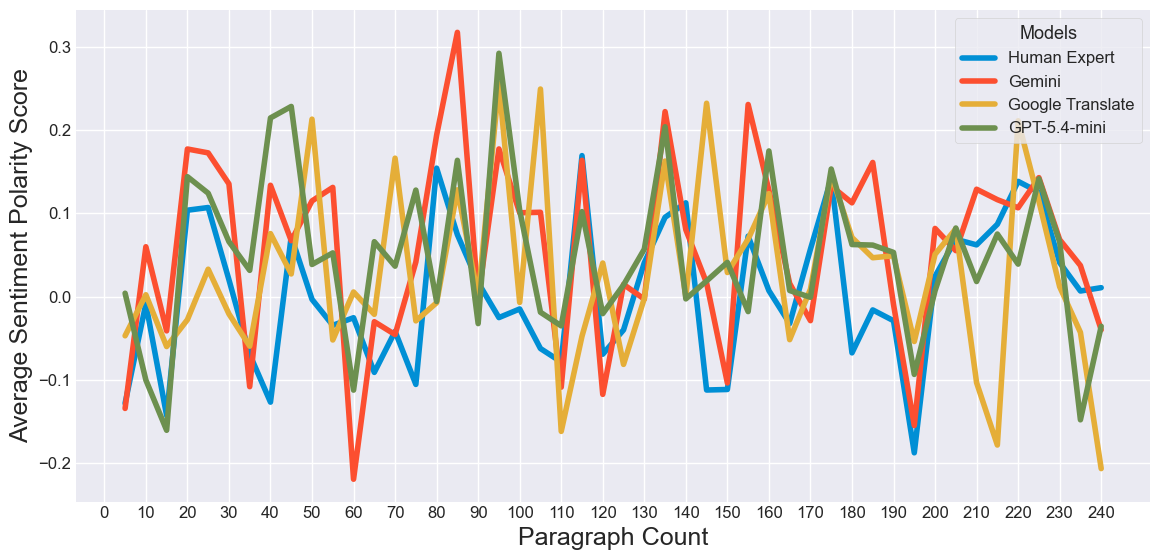

In [131]:
file_paths = [
    'Data/Georgian/Vazha_ThreePoems/en/combined_vazha_poems_en.csv',
    'Data/Georgian/Vazha_ThreePoems/gem/combined_vazha_poems_gem.csv',
    'Data/Georgian/Vazha_ThreePoems/ggl/combined_vazha_poems_ggl.csv',
    'Data/Georgian/Vazha_ThreePoems/gpt/combined_vazha_poems_gpt.csv',
]

labels = ['Human Expert', 'Gemini', 'Google Translate','GPT-5.4-mini']

output_path = 'results/ge_poems/sentiment/graphs/polarity.png'
plot_textblob_polarity(file_paths, labels, output_path, 5, 10)

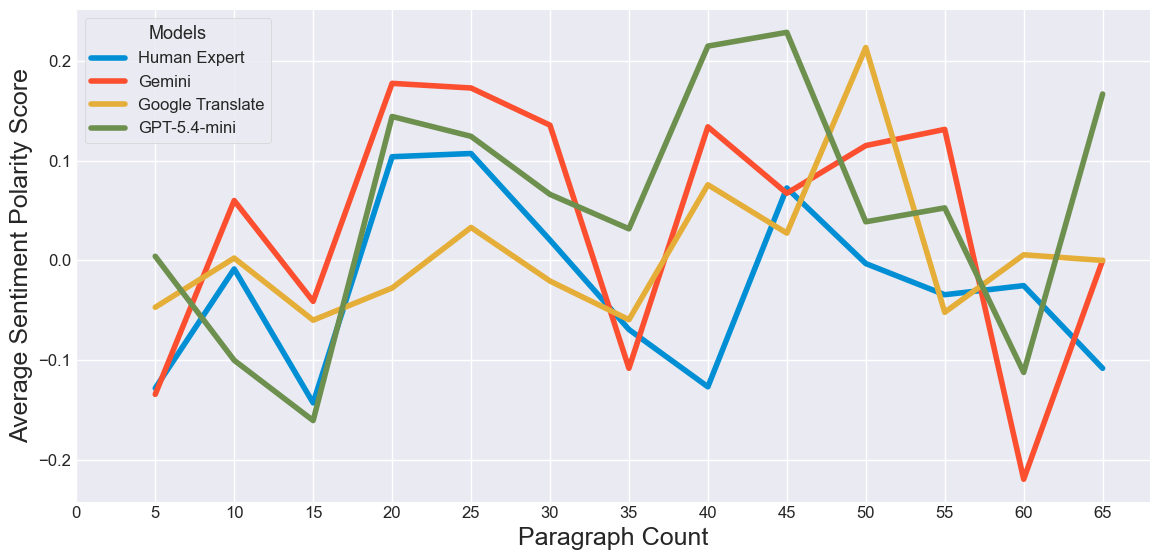

In [132]:
sentiment_files = [
    'results/ge_poems/sentiment/en/01_aluda_ketelauri_ge.csv',
    'results/ge_poems/sentiment/gem/01_aluda_ketelauri_ge.csv',
    'results/ge_poems/sentiment/ggl/01_aluda_ketelauri_ge.csv',
    'results/ge_poems/sentiment/gpt/01_aluda_ketelauri_ge.csv',
]

labels = ['Human Expert', 'Gemini', 'Google Translate', 'GPT-5.4-mini']

output_path = 'results/ge_poems/sentiment/graphs/polarity_01_aluda_ketelauri_ge.png'

plot_textblob_polarity(sentiment_files, labels, output_path, 5, 5)

In [133]:
#Bulgarian prose

texts_path = 'Data/Bulgarian/BaiGanyo/'

In [134]:
file_paths = ["orig/baiganyo_combined_master_bul.csv", 
              "en/baiganyo_combined_master_en.csv",
              "gem/baiganyo_combined_master_gem.csv",
              "ggl/baiganyo_combined_master_ggl.csv",
              "gpt/baiganyo_combined_master_gpt.csv"]

OUTPUT_BASE = 'results/bul_prose/sentiment/'

article_names, df_orig, df_en, df_ggl, df_gem, df_gpt = text_name(texts_path, file_paths)
text_df(OUTPUT_BASE, article_names, df_orig, df_en, df_ggl, df_gem, df_gpt)

['00_bai_ganyo_starts_out_for_europe_bul.csv', '01_bai_ganyo_sets_off_bul.csv', '02_bai_ganyo_at_the_opera_bul.csv', '03_bai_ganyo_at_the_baths_bul.csv', '04_bai_ganyo_in_dresden_bul.csv', '05_bai_ganyo_at_the_prague_exhibition_bul.csv', '06_bai_ganyo_at_jirecheks_bul.csv', '07_bai_ganyo_goes_visiting_bul.csv', '08_bai_ganyo_in_switzerland_bul.csv', '09_bai_ganyo_in_russia_bul.csv', '10_bai_ganyo_returns_from_europe_bul.csv', '11_bai_ganyo_does_elections_bul.csv', '12_bai_ganyo_the_journalist_bul.csv', '13_bai_ganyo_at_the_palace_bul.csv', '14_bai_ganyo_in_the_delegation_bul.csv', '15_bai_ganyo_in_the_opposition_bul.csv', '16_the_temperance_society_bul.csv', '17_letter_from_bai_ganyo_to_konstantin_velichkov_bul.csv', '18_from_the_correspondence_of_bai_ganyo_balkanski_bul.csv']
19
Saved: results/bul_prose/sentiment/orig/00_bai_ganyo_starts_out_for_europe_bul.csv
Saved: results/bul_prose/sentiment/orig/01_bai_ganyo_sets_off_bul.csv
Saved: results/bul_prose/sentiment/orig/02_bai_ganyo_at_

  Sentiment  Count  Count  Count  Count
0      love    112    103     98     96
1       joy    265    242    259    281
2     anger     73     79     63     61
3   sadness     22     21     14     23
4      fear      2      7      2      6
5  surprise     44     41     40     32
6   neutral    745    741    746    738
  Sentiment  English  Google  Gemini  ChatGPT
0      love      112     103      98       96
1       joy      265     242     259      281
2     anger       73      79      63       61
3   sadness       22      21      14       23
4      fear        2       7       2        6
5  surprise       44      41      40       32
6   neutral      745     741     746      738
0   Models love  joy anger sadness fear surprise neutral
0  English  112  265    73      22    2       44     745
1   Google  103  242    79      21    7       41     741
2   Gemini   98  259    63      14    2       40     746
3  ChatGPT   96  281    61      23    6       32     738
Index(['Models', 'love', 'j

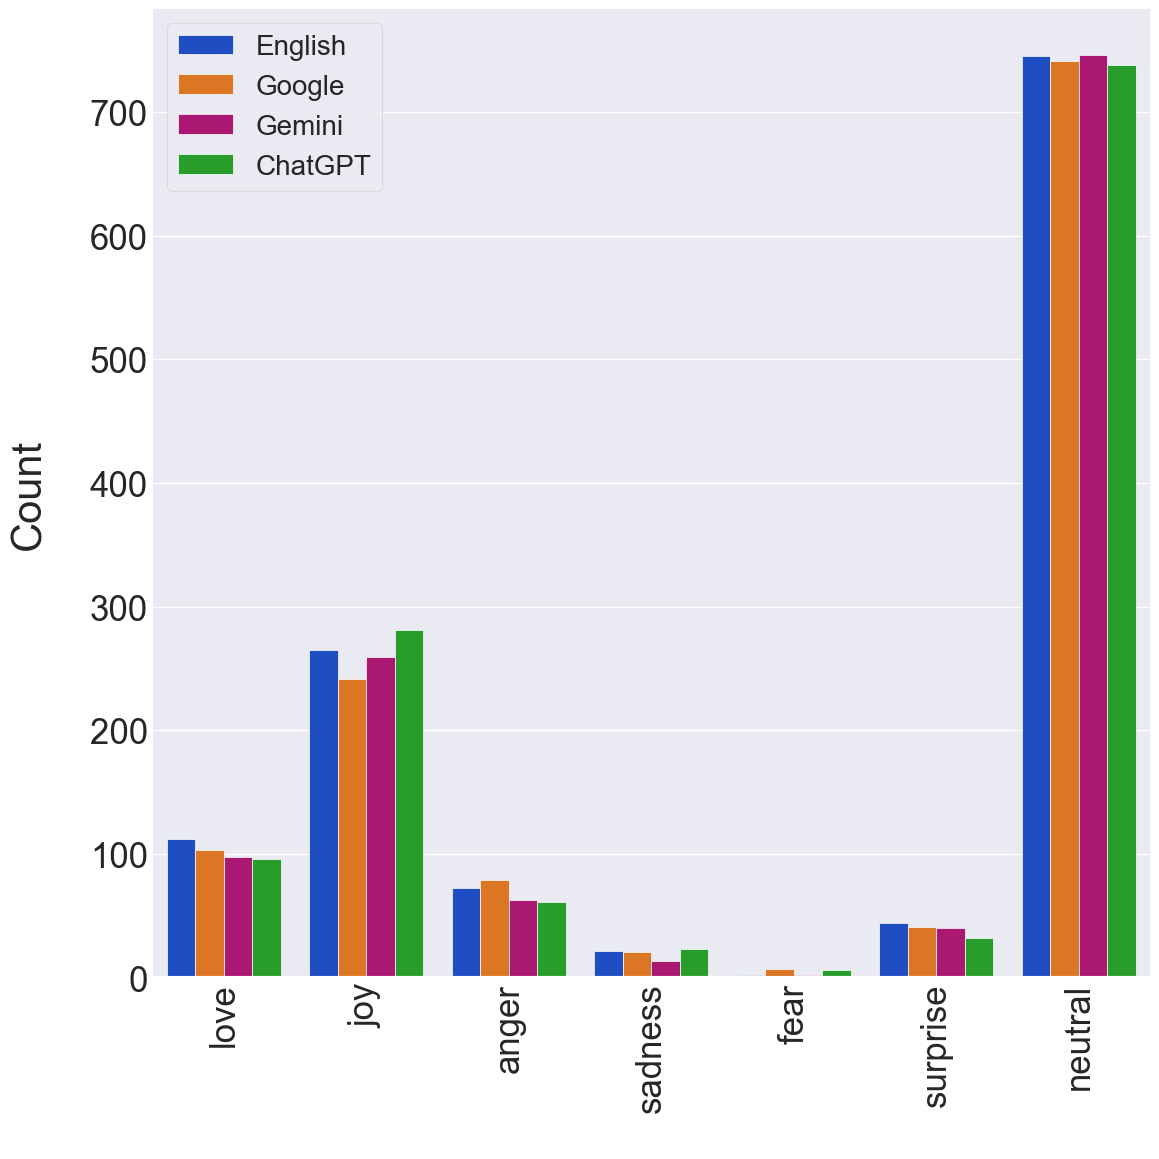

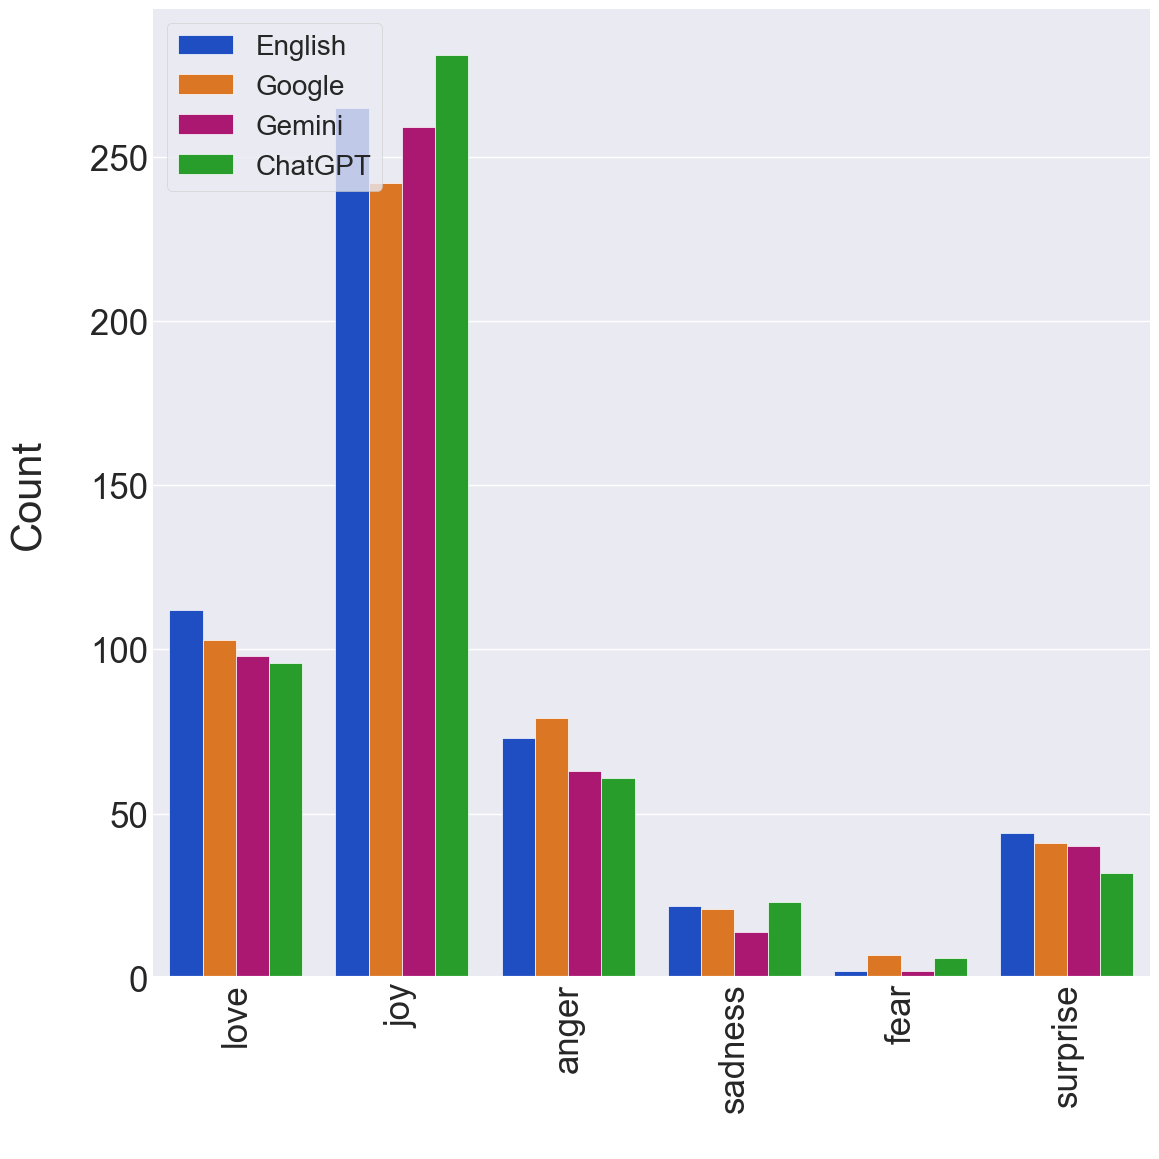

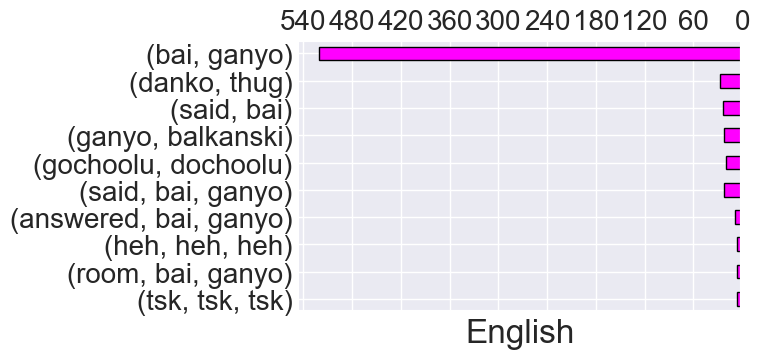

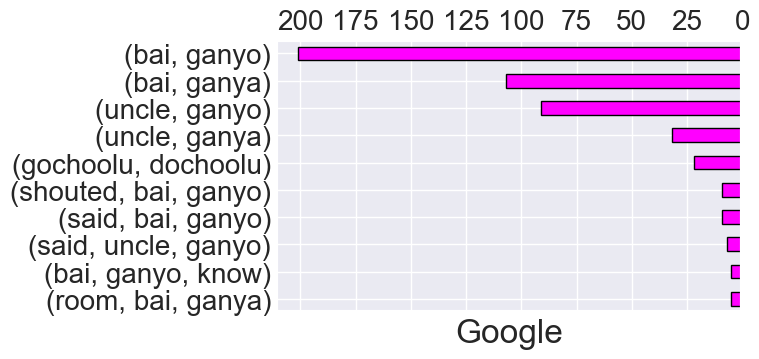

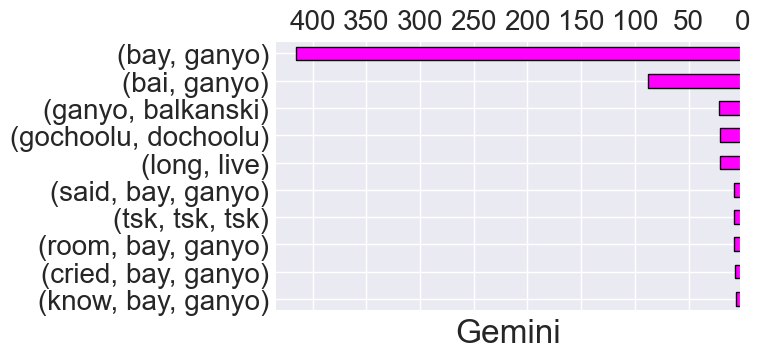

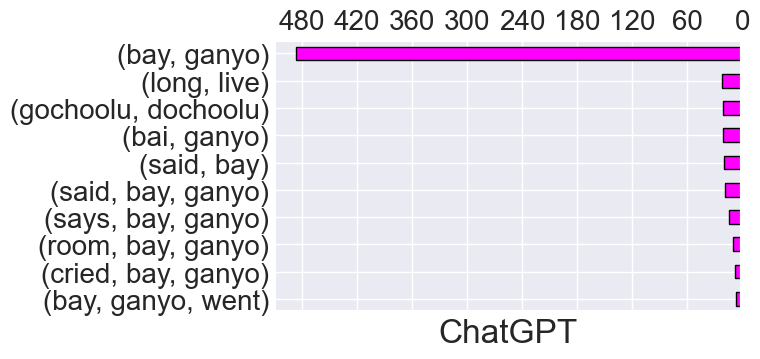

In [135]:
sentiment_bar(OUTPUT_BASE, 'results/bul_prose/sentiment/graphs/sentiment_all_bar.png', 'upper left', all_article_dataframe)
sentiment_bar(OUTPUT_BASE, 'results/ge_poems/sentiment/graphs/sentiment_all_bar.png', 'upper left', all_article_dataframe_no_neutral)

topic_df = topic('en/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

output_graphs = os.path.join(OUTPUT_BASE, 'graphs')
os.makedirs(output_graphs, exist_ok = True)

ngrams_graphs(text, 'English', OUTPUT_BASE)

topic_df = topic('ggl/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Google', OUTPUT_BASE)

topic_df = topic('gem/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Gemini', OUTPUT_BASE)

topic_df = topic('gpt/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'ChatGPT', OUTPUT_BASE)

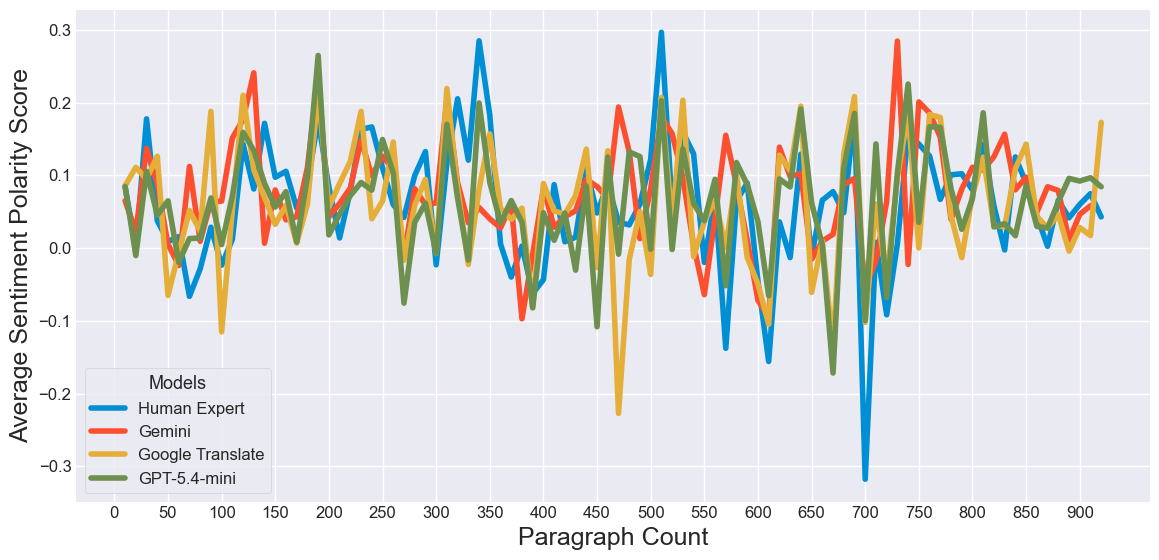

In [136]:
#Gemini was unable to translate some lines

file_paths = [
    'Data/Bulgarian/BaiGanyo/en/baiganyo_combined_master_en.csv',
    'Data/Bulgarian/BaiGanyo/gem/baiganyo_combined_master_gem.csv',
    'Data/Bulgarian/BaiGanyo/ggl/baiganyo_combined_master_ggl.csv',
    'Data/Bulgarian/BaiGanyo/gpt/baiganyo_combined_master_gpt.csv',
]

labels = ['Human Expert', 'Gemini', 'Google Translate','GPT-5.4-mini']

output_path = 'results/bul_prose/sentiment/graphs/polarity.png'
plot_textblob_polarity(file_paths, labels, output_path, 10, 50)

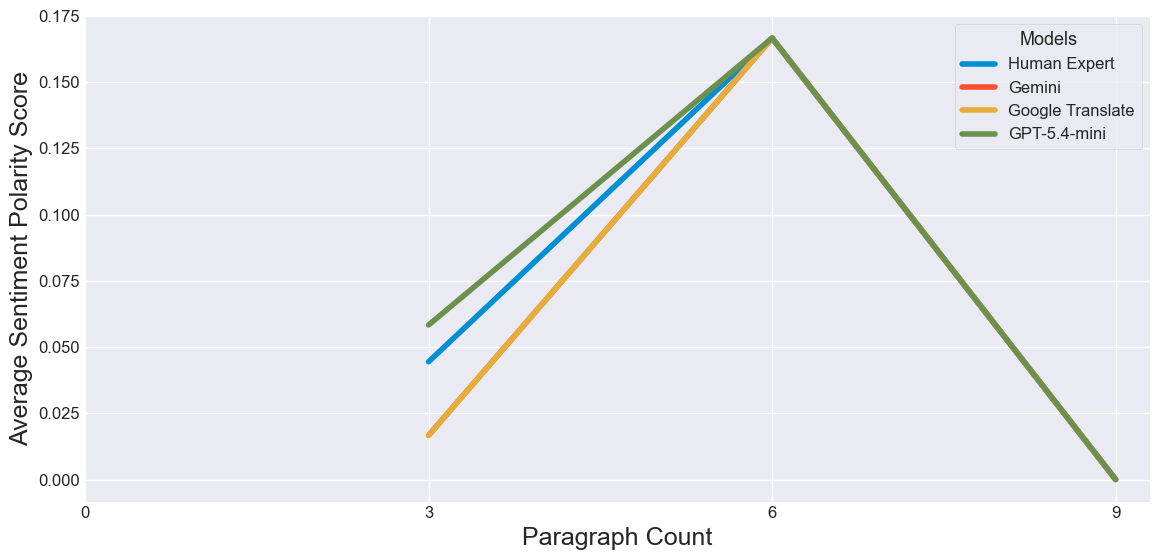

In [137]:
sentiment_files = [
    'results/bul_prose/sentiment/en/00_bai_ganyo_starts_out_for_europe_bul.csv',
    'results/bul_prose/sentiment/gem/00_bai_ganyo_starts_out_for_europe_bul.csv',
    'results/bul_prose/sentiment/ggl/00_bai_ganyo_starts_out_for_europe_bul.csv',
    'results/bul_prose/sentiment/gpt/00_bai_ganyo_starts_out_for_europe_bul.csv',
]

labels = ['Human Expert', 'Gemini', 'Google Translate', 'GPT-5.4-mini']

output_path = 'results/bul_prose/sentiment/graphs/polarity_00_bai_ganyo_starts_out_for_europe_bul.png'

plot_textblob_polarity(sentiment_files, labels, output_path, 3, 3)